# DataLeague Datathon - Manipulation and Anomaly Detection

This notebook is the jury-facing runner. The reusable implementation lives in `datathon_pipeline.py`.

In [1]:
import importlib.util
import subprocess
import sys

missing = [pkg for pkg in ["duckdb", "matplotlib"] if importlib.util.find_spec(pkg) is None]
if missing:
    print("Installing missing packages:", missing)
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    except subprocess.CalledProcessError as exc:
        raise RuntimeError("Install failed. If you see externally-managed-environment, create a venv and select .venv/bin/python as this notebook kernel. See README.md.") from exc
else:
    print("Runtime dependencies are ready.")

Runtime dependencies are ready.


In [2]:
from pathlib import Path
import importlib
import pandas as pd

import datathon_pipeline as dp
dp = importlib.reload(dp)

DATA_PATH = dp.DATA_PATH
ARTIFACT_DIR = dp.ARTIFACT_DIR
inspect_dataset = dp.inspect_dataset
run_pipeline = dp.run_pipeline
predict_live = dp.predict_live
load_context = dp.load_context

print("Pipeline version:", dp.MODEL_VERSION)

DATA_PATH, ARTIFACT_DIR

Pipeline version: text-calibration-v6-credential-finance-patterns


(PosixPath('dataset/datathonFINAL.parquet'), PosixPath('artifacts'))

## 1. Dataset Check

In [3]:
info = inspect_dataset(DATA_PATH)
print("Rows:", f"{info['row_count']:,}")
display(info["schema"])
display(info["date_range"])

Rows: 5,004,813


,column_name,column_type,null,key,default,extra
0,original_text,VARCHAR,YES,None,None,None
1,english_keywords,VARCHAR,YES,None,None,None
2,sentiment,DOUBLE,YES,None,None,None
3,main_emotion,VARCHAR,YES,None,None,None
4,primary_theme,VARCHAR,YES,None,None,None
5,language,VARCHAR,YES,None,None,None
6,url,VARCHAR,YES,None,None,None
7,author_hash,VARCHAR,YES,None,None,None
8,date,VARCHAR,YES,None,None,None


,min_date,max_date
0,2024-11-14 19:00:00,2024-11-24 19:10:32


## 2. Score Sample and Build Artifacts

Increase `SAMPLE_SIZE` if you have time. Use 20k-50k for a fast demo, 200k+ for the final run.

In [4]:
SAMPLE_SIZE = 200_000

scored, context, summary = run_pipeline(
    data_path=DATA_PATH,
    artifacts_dir=ARTIFACT_DIR,
    sample_size=SAMPLE_SIZE,
    use_full_author_stats=True,
    make_plots=True,
)
summary

{'created_at': '2026-04-27T12:08:52.908375+00:00',
 'data_path': 'dataset/datathonFINAL.parquet',
 'sample_size_requested': 200000,
 'risk_threshold': 0.65,
 'review_threshold': 0.45,
 'plots': ['artifacts/risk_score_histogram.png',
  'artifacts/risk_map_language_platform.png',
  'artifacts/language_manipulative_share.png',
  'artifacts/top_suspicious_segments.png',
  'artifacts/platform_normalized_risk.png',
  'artifacts/top_risk_authors.png',
  'artifacts/hourly_suspicious_share.png',
  'artifacts/temporal_burst_windows.png',
  'artifacts/risk_funnel.png',
  'artifacts/reason_code_breakdown.png',
  'artifacts/psychological_trigger_breakdown.png',
  'artifacts/live_inference_benchmark.png',
  'artifacts/coordination_confidence_bubble.png',
  'artifacts/evidence_quality_summary.png',
  'artifacts/feature_importance_proxy.png',
  'artifacts/risk_component_contribution.png'],
 'case_studies_path': 'artifacts/case_studies.md',
 'suspicious_count': 8033,
 'high_risk_count': 3663,
 'review_

## 3. Highest Risk Non-Empty Examples and Empty Text Anomalies

In [5]:
cols = [
    "risk_score", "risk_band", "organic_score", "label", "reason_codes",
    "content_risk", "author_risk", "coordination_risk",
    "language", "platform_domain", "primary_theme", "author_hash",
    "cluster_size", "cluster_author_nunique", "cluster_confidence_score",
    "stripped_char_len", "original_text"
]
existing = [c for c in cols if c in scored.columns]

print("Empty text anomalies are treated as high risk, but separated from content examples.")
empty_summary = (
    scored[scored["reason_codes"].fillna("").str.contains("EMPTY_TEXT")]
    .groupby(["platform_domain", "language"], dropna=False)
    .size()
    .reset_index(name="empty_text_posts")
    .sort_values("empty_text_posts", ascending=False)
)
display(empty_summary.head(10))

print("Highest risk examples with real text content")
non_empty_examples = scored[scored["stripped_char_len"].fillna(0) >= 20].copy()
display(
    non_empty_examples
    .sort_values(["risk_score", "coordination_risk", "author_risk"], ascending=False)
    [existing]
    .head(20)
)

Empty text anomalies are treated as high risk, but separated from content examples.


,platform_domain,language,empty_text_posts
2,x.com,en,148
0,bsky.app,km,4
1,reddit.com,en,1


Highest risk examples with real text content


,risk_score,risk_band,organic_score,label,reason_codes,content_risk,author_risk,coordination_risk,language,platform_domain,primary_theme,author_hash,cluster_size,cluster_author_nunique,cluster_confidence_score,stripped_char_len,original_text
4243,0.820000,High,0.180000,Manipulative,LINK_HASHTAG_MENTION_DENSE,0.82,0.000000,0.0,en,reddit.com,Technology,4f4d0ea387a460033cd8b8560186b8c19d1c2ede,NaN,NaN,NaN,36.0,https://www.youtube.com/watch?v=uFpK
14033,0.820000,High,0.180000,Manipulative,LINK_HASHTAG_MENTION_DENSE;HIGH_UPPERCASE_RATIO,0.82,0.000000,0.0,ja,bsky.app,Entertainment,b37296078f3c812060ea7cba9d5f57745c2dce94,NaN,NaN,NaN,33.0,WATCH THE SUPER SHOW! #mario #art
44180,0.820000,High,0.180000,Manipulative,LINK_HASHTAG_MENTION_DENSE,0.82,0.000000,0.0,en,bsky.app,Entertainment,e13a2a7fb0790b9279664ad3af1f8b28d6cf5ad3,NaN,NaN,NaN,31.0,www.youtube.com/watch?v=Ixsd...
48777,0.820000,High,0.180000,Manipulative,ENGAGEMENT_OR_LINK_BAIT,0.82,0.000000,0.0,en,x.com,Sports,d06f634866f93f6fafce77cc88e543f573c1e21c,NaN,NaN,NaN,30.0,Follow for more #Cubs content!
64193,0.820000,High,0.180000,Manipulative,LINK_HASHTAG_MENTION_DENSE;PUNCTUATION_BURST,0.82,0.000000,0.0,en,bsky.app,Entertainment,65fcaa899b6576120d740649b9501e991d91cb9c,NaN,NaN,NaN,49.0,music.youtube.com/watch?v=TXUZ...\nCurrent moo...
91782,0.820000,High,0.180000,Manipulative,LINK_HASHTAG_MENTION_DENSE,0.82,0.000000,0.0,en,x.com,Social,a3ad58aeaa94f23d31df8a8b2a7ee2264362e5ad,NaN,NaN,NaN,27.0,When \n@plies\n gonna join ?
99584,0.820000,High,0.180000,Manipulative,VERY_SHORT_TEXT;LINK_HASHTAG_MENTION_DENSE;PUN...,0.82,0.000000,0.0,en,x.com,Cryptocurrency,8a46d86fdfa02d008a54db5d321fc4071b57c526,NaN,NaN,NaN,22.0,Excited to watch! #XRP
99749,0.820000,High,0.180000,Manipulative,ENGAGEMENT_OR_LINK_BAIT,0.82,0.000000,0.0,es,x.com,Technology,e5a67d616a1fe6d496a5dff5ea9108fdc1769224,NaN,NaN,NaN,33.0,@jrcst\n amigo puedes mirar el dm?
127389,0.820000,High,0.180000,Manipulative,VERY_SHORT_TEXT;LINK_HASHTAG_MENTION_DENSE;PUN...,0.82,0.000000,0.0,en,x.com,People,30862630387a5c03a4409876495b78033f8782b0,NaN,NaN,NaN,23.0,"Or...trust, but verify?"
167845,0.820000,High,0.180000,Manipulative,LINK_HASHTAG_MENTION_DENSE;PUNCTUATION_BURST,0.82,0.000000,0.0,en,x.com,Sports,,NaN,NaN,NaN,25.0,BULLDOGS WIN!!\n\n#Shriners


## 4. Manipulation Map Artifacts

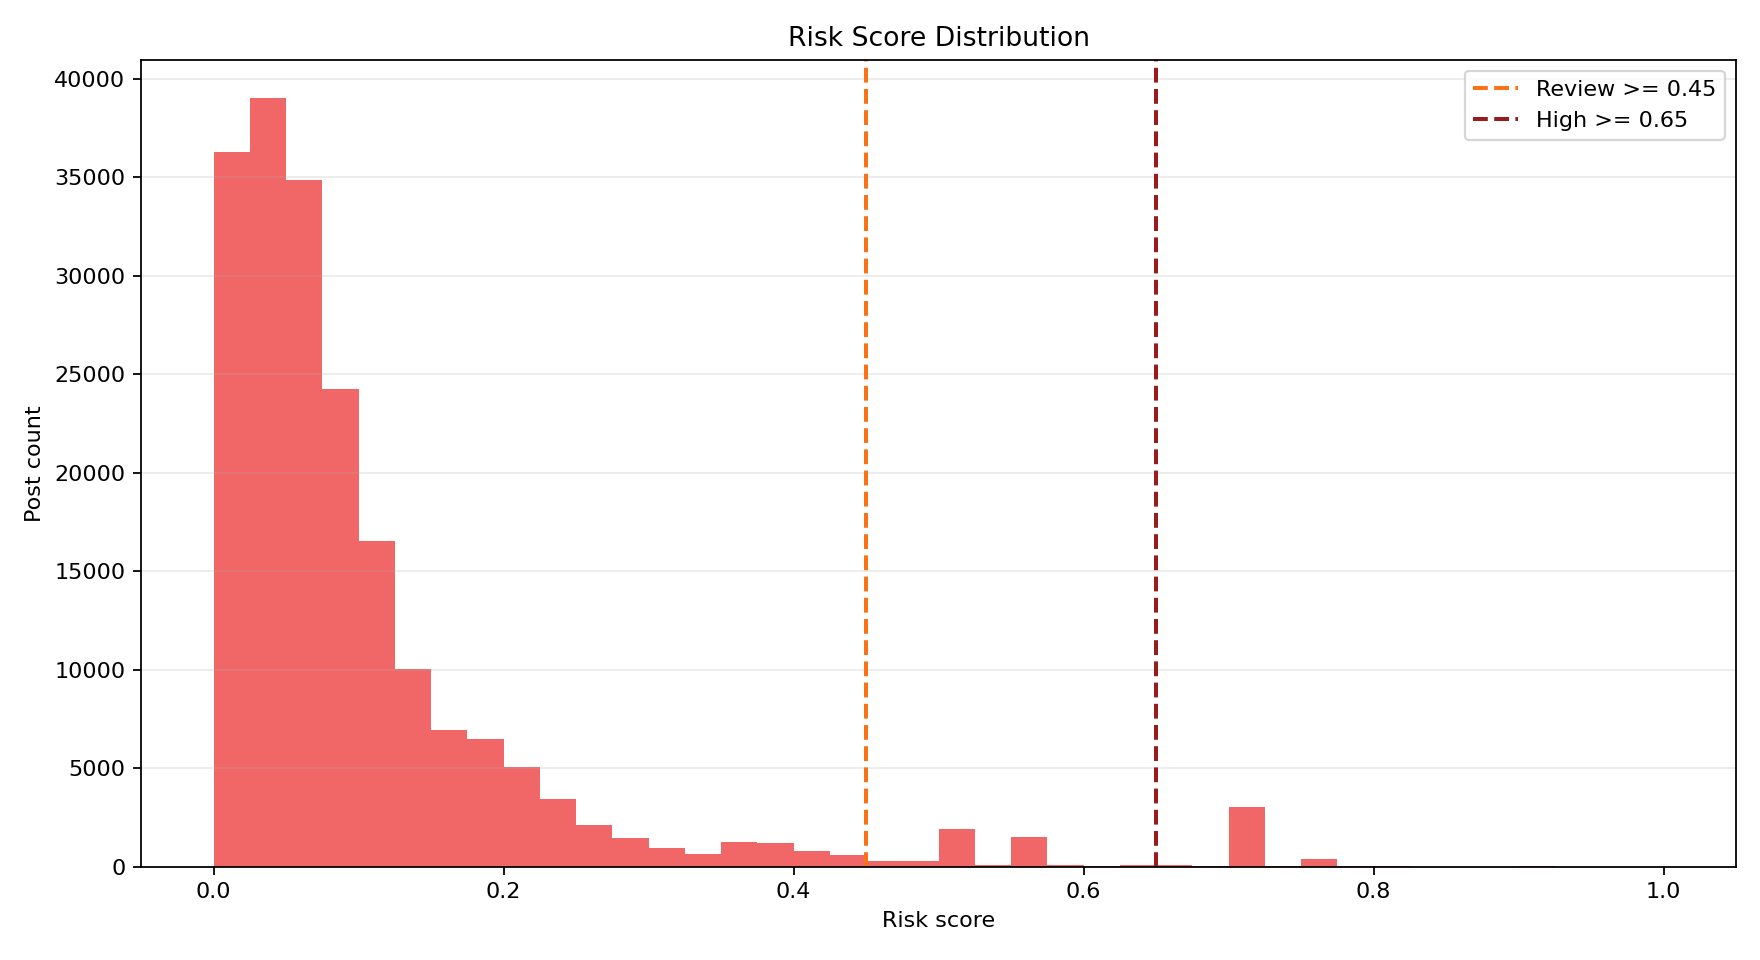

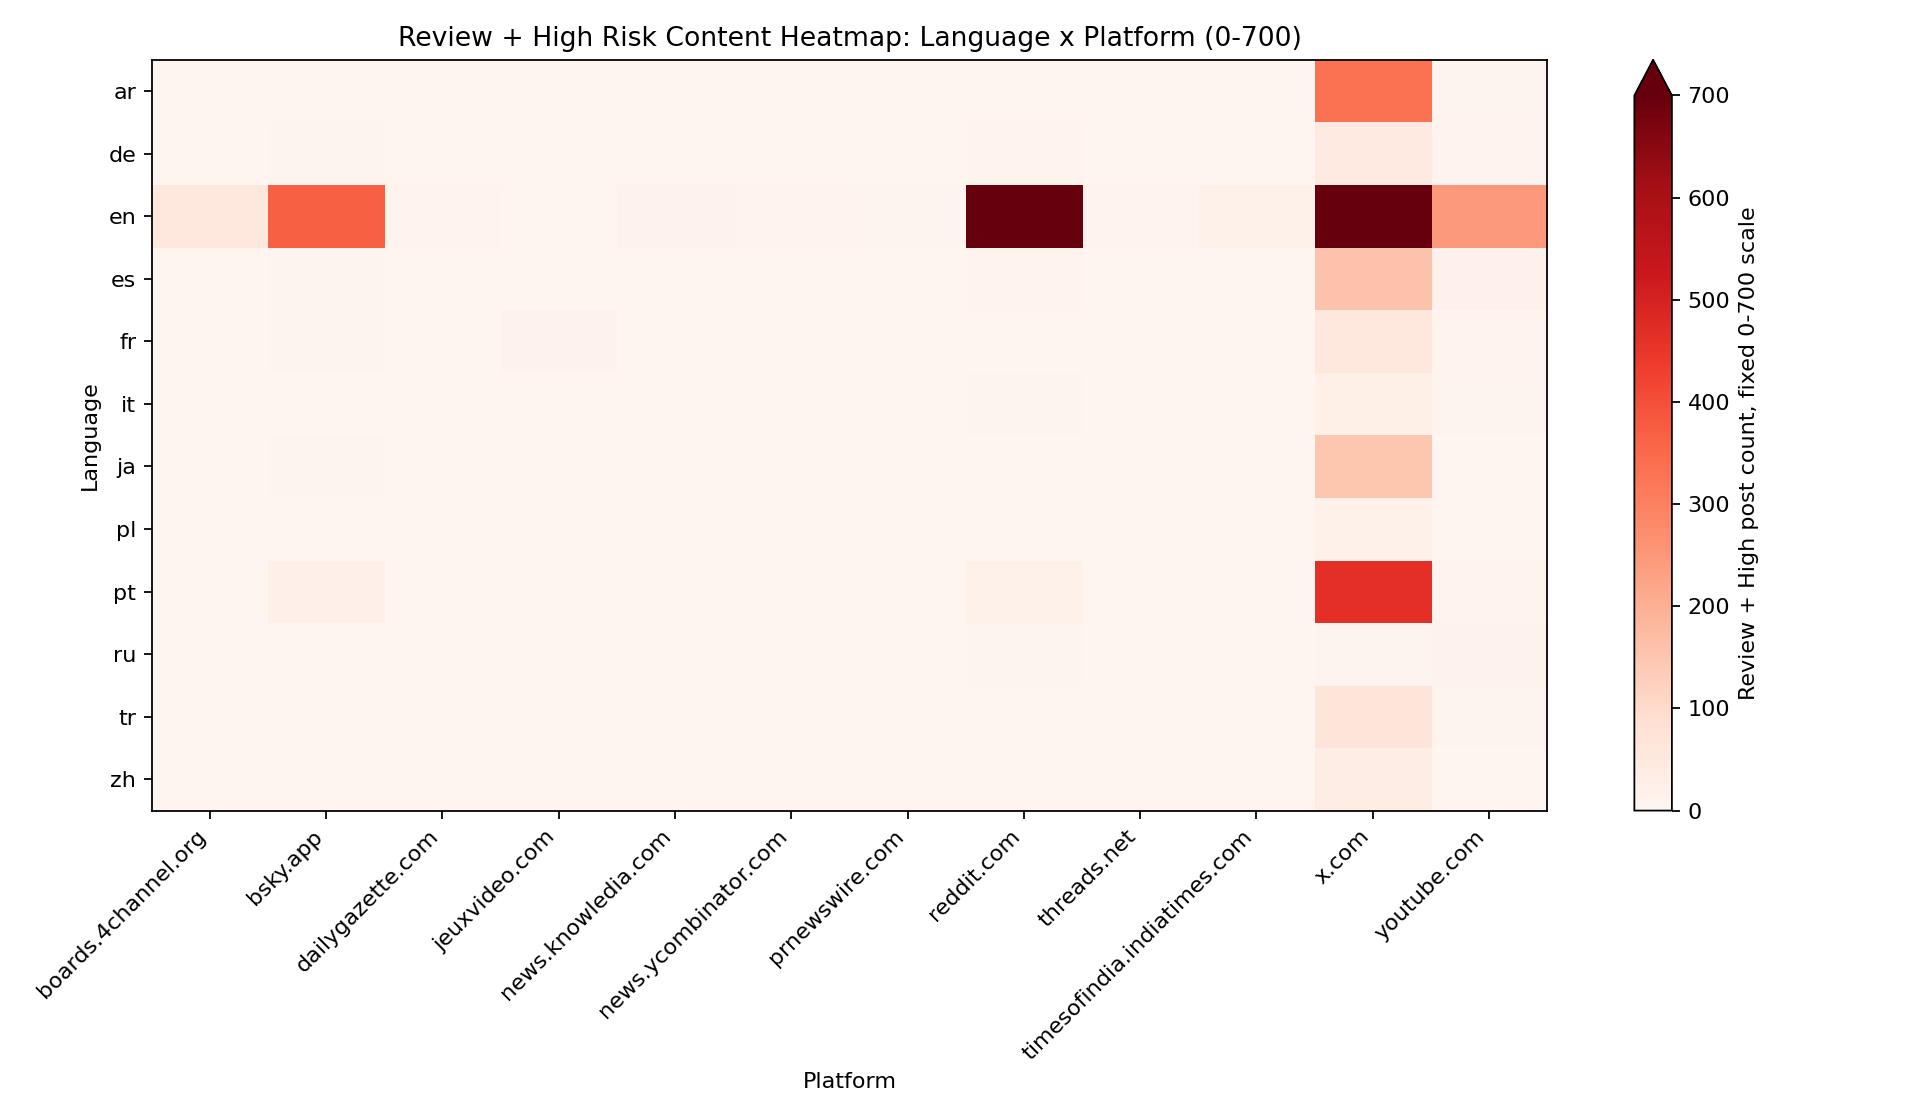

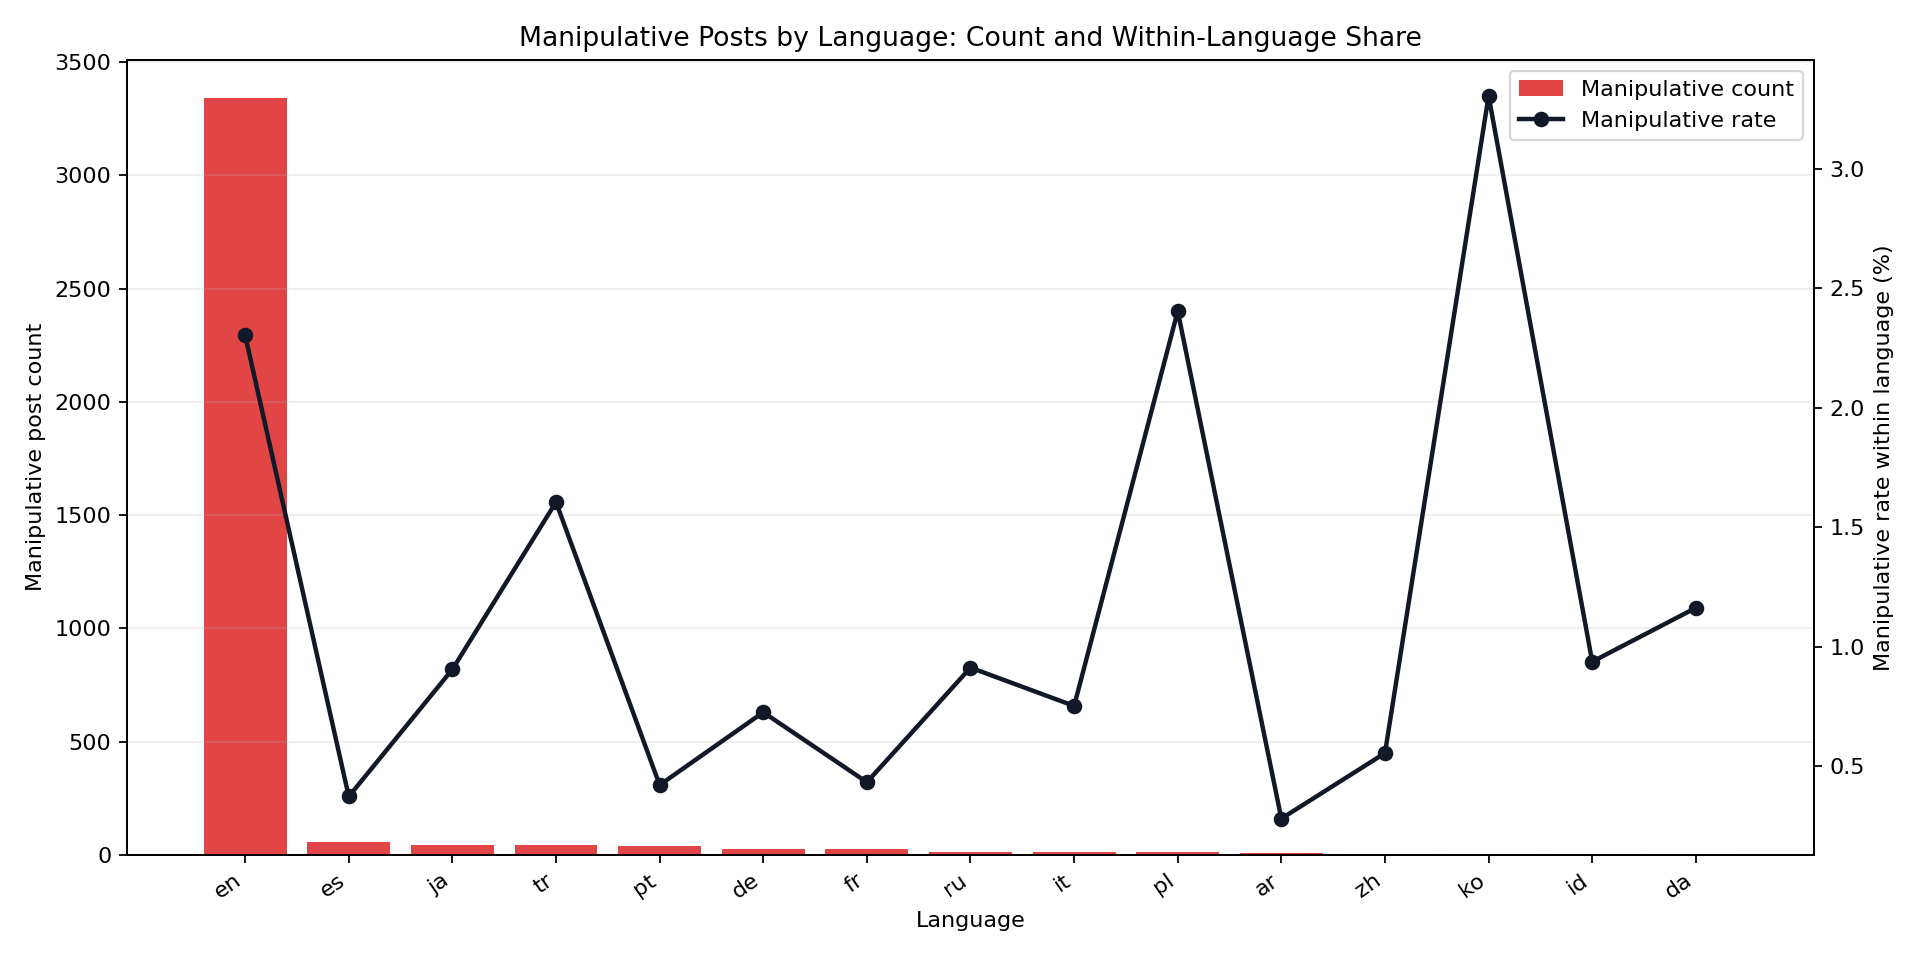

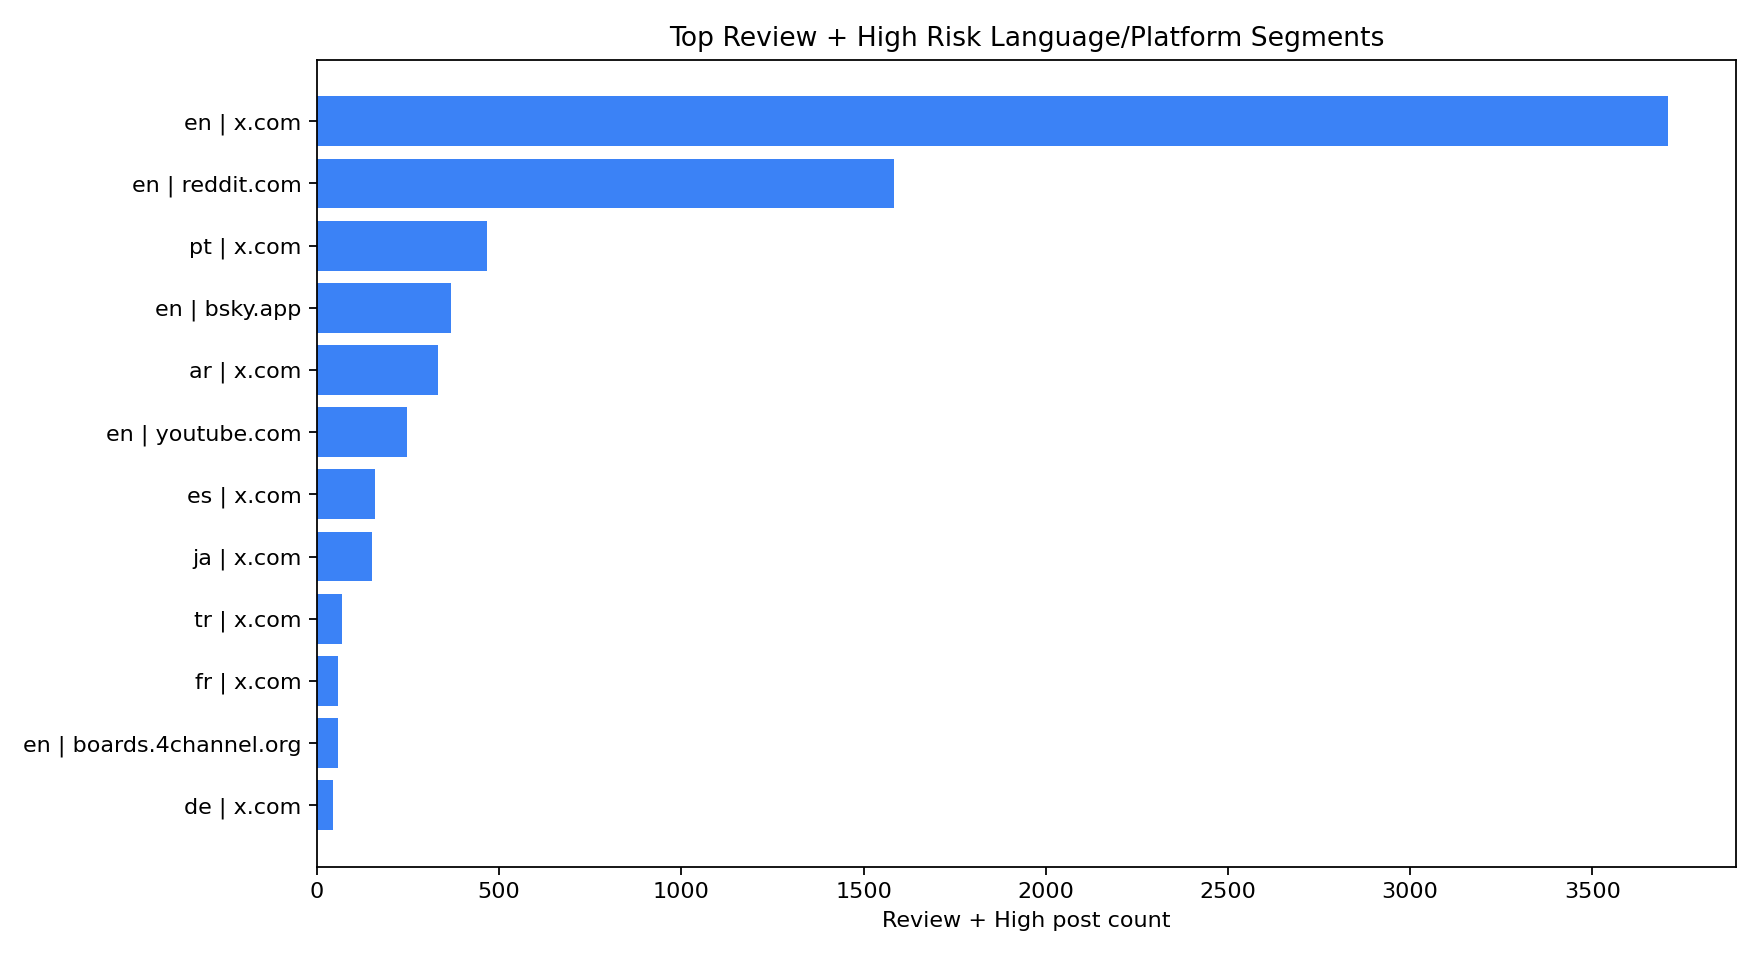

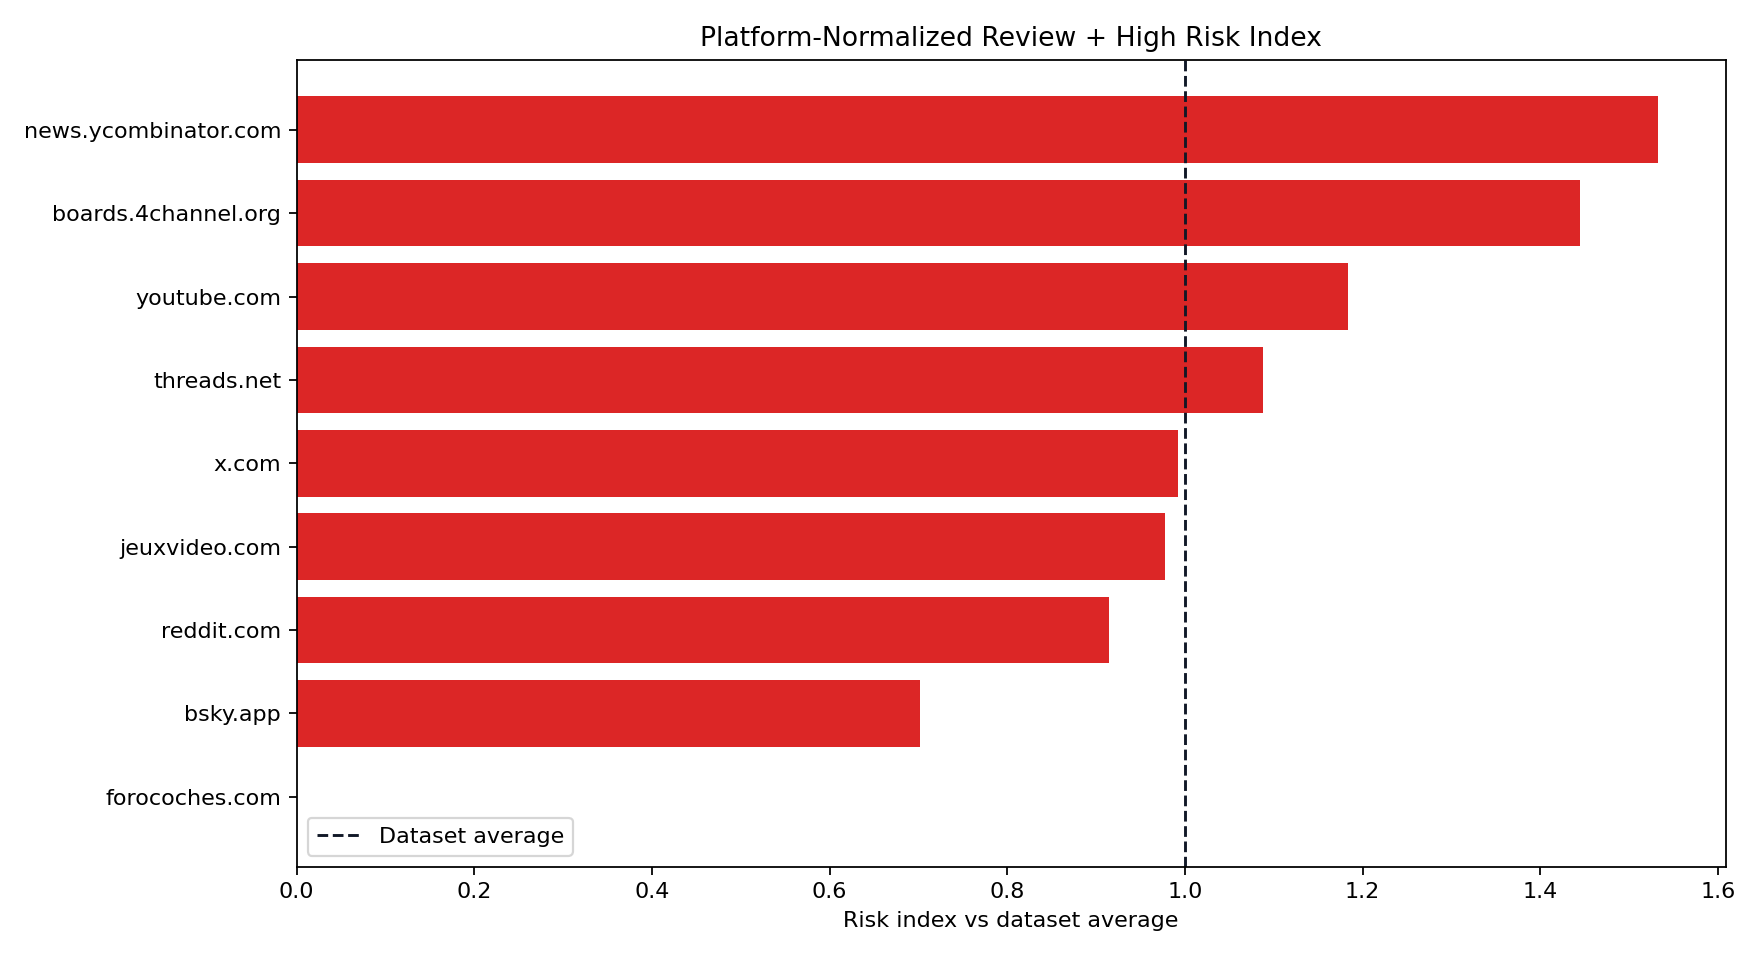

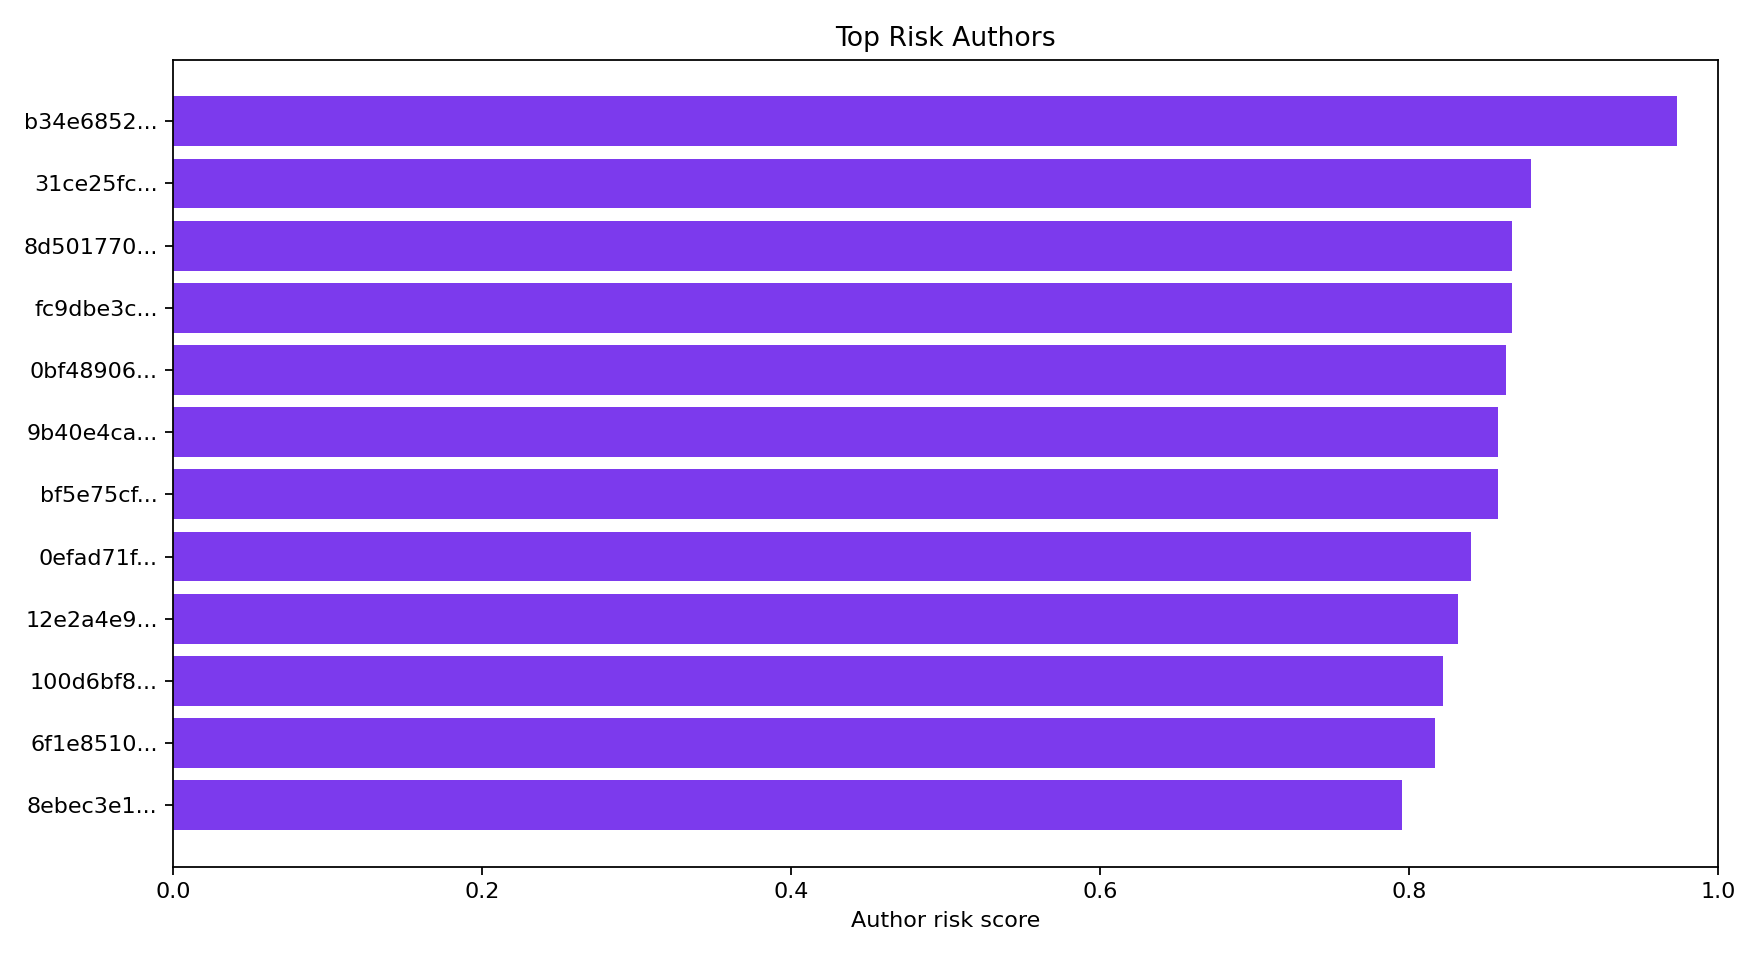

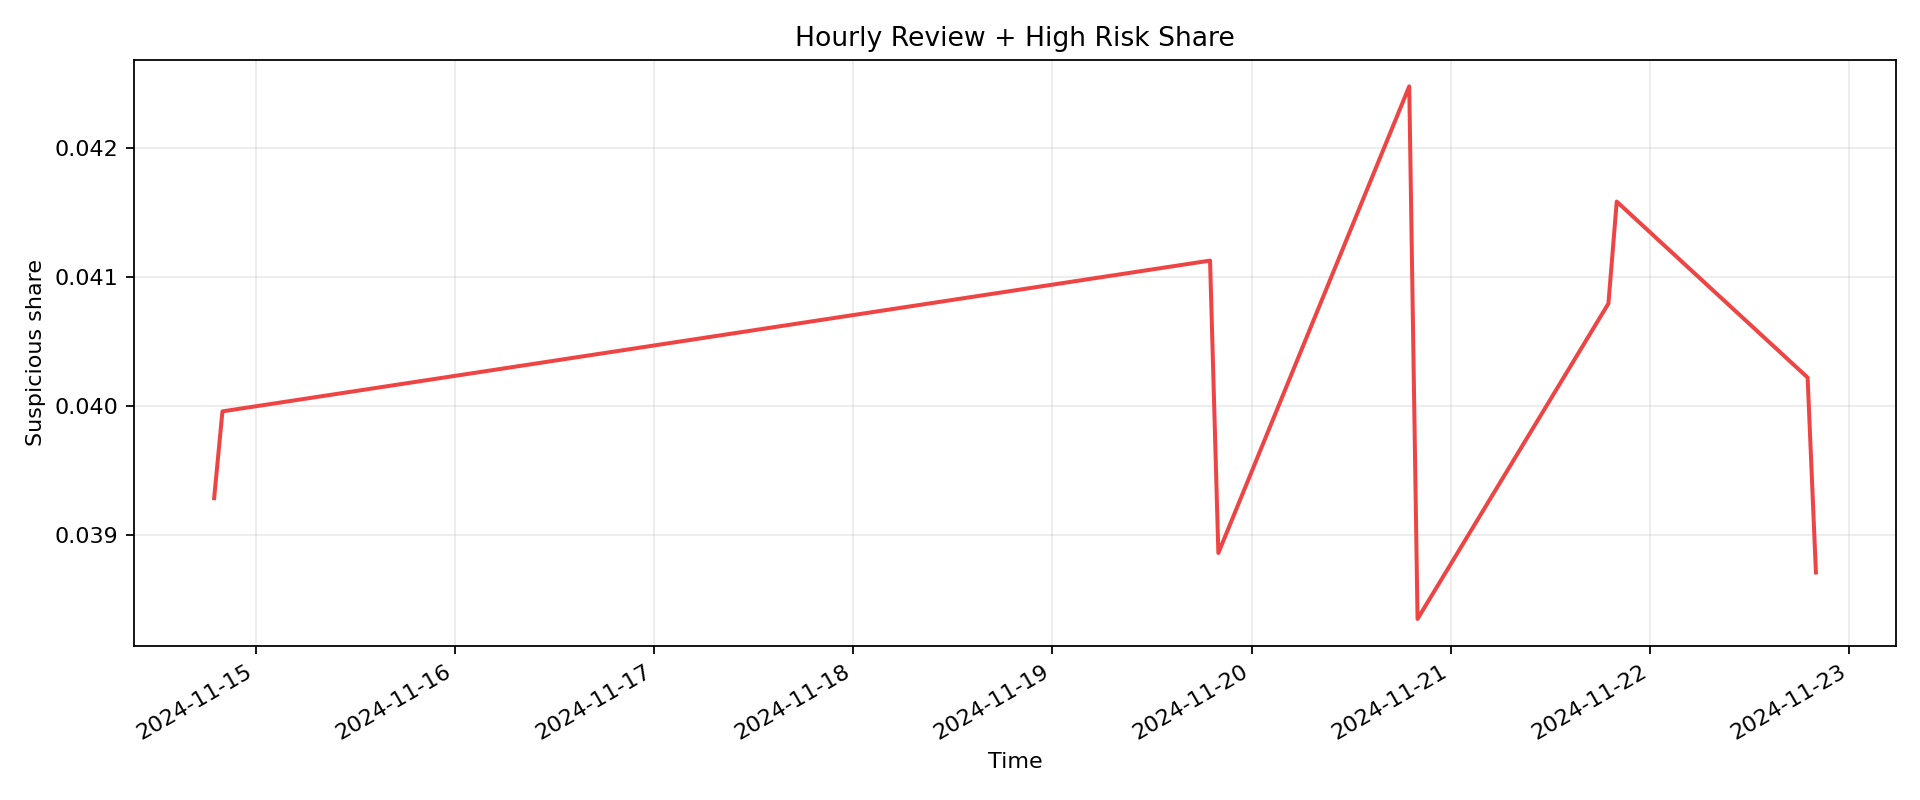

,language,platform_domain,primary_theme,suspicious_posts,high_posts,review_posts,avg_risk,unique_authors,narratives
0,en,x.com,Cryptocurrency,799,484,315,0.639645,610,768
1,en,x.com,Technology,544,333,211,0.643207,396,538
2,en,x.com,People,505,198,307,0.628298,252,355
3,en,reddit.com,Technology,459,346,113,0.685804,92,457
4,en,x.com,Entertainment,420,147,273,0.596227,195,416
5,en,x.com,Social,330,188,142,0.631045,177,302
6,en,x.com,Politics,269,117,152,0.600855,194,268
7,en,reddit.com,Entertainment,204,102,102,0.627622,80,204
8,en,reddit.com,People,200,99,101,0.620090,82,200
9,en,reddit.com,Social,172,138,34,0.703241,23,165


,platform_domain,posts,high_posts,review_posts,avg_risk,max_risk,review_high_posts,review_high_rate,high_rate,platform_normalized_risk_index,platform_high_risk_index,sufficient_sample
0,news.ycombinator.com,130,7,1,0.158858,0.720000,8,0.061538,0.053846,1.532141,2.940003,True
1,boards.4channel.org,1017,25,34,0.386847,0.732215,59,0.058014,0.024582,1.444386,1.342184,True
2,youtube.com,6708,174,145,0.088788,0.720000,319,0.047555,0.025939,1.183995,1.416280,True
3,threads.net,183,4,4,0.109783,0.720000,8,0.043716,0.021858,1.088406,1.193444,True
4,x.com,128645,2095,3030,0.108342,0.920000,5125,0.039838,0.016285,0.991866,0.889169,True
5,jeuxvideo.com,331,5,8,0.076557,0.720000,13,0.039275,0.015106,0.977840,0.824774,True
6,reddit.com,44855,1034,613,0.092392,0.920000,1647,0.036718,0.023052,0.914187,1.258644,True
7,bsky.app,14623,203,209,0.097922,0.920000,412,0.028175,0.013882,0.701476,0.757971,True
8,forocoches.com,211,0,0,0.066773,0.303350,0,0.000000,0.000000,0.000000,0.000000,True
9,postandcourier.com,7,1,6,0.533252,0.752055,7,1.000000,0.142857,24.897299,7.800008,False


,author_hash,sample_posts,high_posts,review_posts,avg_risk,max_risk,author_risk,author_volume_risk,author_burst_risk,author_repeat_risk,author_low_theme_diversity_risk,author_post_count_full,platform_nunique,theme_nunique,language_nunique,example_text,review_high_posts,review_high_share
0,b34e6852dfc57a38fdf638762c25154929905538,304,0,304,0.505709,0.536704,0.972953,1.0,0.910891,0.996711,0.973684,7950.0,1,8,2,برشلونة أروكا إستريلا دا أمادورا باريس سان جير...,304,1.000000
1,31ce25fc2791c7dbf8a8117d4ffccbcb7ad315c6,8,0,0,0.425672,0.439133,0.878571,1.0,0.714286,0.875000,0.875000,81.0,1,1,1,预约安排！正在营业！2024/11/15 3:07:01,0,0.000000
2,8d501770c735a0e8f5fdd5e408f68e8c4957366f,3,3,0,0.787692,0.787692,0.866667,1.0,1.000000,0.666667,0.666667,46.0,1,1,1,Free 3 to 5 signals available everyday in my c...,3,1.000000
3,fc9dbe3c166164a3932b7934c035aa098517fd10,3,0,0,0.404890,0.404890,0.866667,1.0,1.000000,0.666667,0.666667,20.0,1,1,1,$Nemo \n$Nwo\n$Forky\n$Ripple Xrp589\n$Skol,0,0.000000
4,0bf489067a5b5819b1b8dc2f396085090eb29249,4,0,4,0.506111,0.508292,0.862500,1.0,1.000000,0.750000,0.500000,52.0,1,2,1,Daily guaranteed profit assurance on stock mar...,4,1.000000
5,9b40e4cab53b8ed451de008fbaaa1855d644da7f,5,5,0,0.891154,0.891154,0.857500,1.0,0.750000,0.800000,0.800000,133.0,1,1,1,NaN,5,1.000000
6,bf5e75cfddd9437eb21965a7226d8856e6e8aa29,5,0,5,0.492965,0.492965,0.857500,1.0,0.750000,0.800000,0.800000,53.0,1,1,1,FreePalestine #Gaza_Genocide #GazaMassacre...,5,1.000000
7,0efad71f30b3568e6d87580d8e3dd2092a550d2c,81,0,2,0.443430,0.455791,0.839660,1.0,0.450000,0.975309,0.888889,2214.0,1,9,1,غو أهيد إيغلز نوتنغهام فورست\n\nڪۆد خضم مباشر\...,2,0.024691
8,12e2a4e9d619017b71dc3e45480237480ecd7053,56,0,3,0.444334,0.475422,0.831412,1.0,0.436364,0.964286,0.875000,1173.0,1,7,1,الفيحاء لانس فيتوريا غيمارايش\n\n▬ستاٮلي▬ ← DOC,3,0.053571
9,100d6bf8ae69fe55412deb0b842151aca38f37e2,342,324,11,0.749675,0.766952,0.821730,1.0,0.926686,0.383041,0.961988,7580.0,1,13,5,This is your friendly automod reminder to PLEA...,335,0.979532


,narrative_signature,coordination_risk,cluster_confidence_score,cluster_content_similarity,cluster_size,cluster_author_nunique,cluster_platform_nunique,cluster_language_nunique,cluster_window_hours,signature_term_count,cluster_example_text
0,kw:#paws|paws|share,0.850000,0.940000,1.0,8.0,8.0,1.0,1.0,0.323056,3.0,Share your #PAWS
1,kw:btc|https|join,0.850000,0.940000,1.0,7.0,7.0,1.0,1.0,1.754444,3.0,https://t.me/onus_tap_tap_tap_bot/join?startap...
2,kw:cinema|cinema history|greatest|greatest vil...,0.760253,0.906883,1.0,4.0,4.0,1.0,1.0,23.551667,7.0,Repost with one of the greatest villains in ci...
3,kw:anniversary|back|memories|nike|nikke,0.758727,0.883067,1.0,4.0,4.0,1.0,1.0,23.941111,5.0,NIKKE 2nd Anniversary。\nニケたちとの2周年の思い出を振り返り、勝利の...
4,kw:aaron|aaron mercury|awards|mercury,0.762500,0.872500,1.0,6.0,4.0,1.0,2.0,1.300833,4.0,AARON MERCURY EN TÚ AWARDS que emoción
5,kw:cult|disciple|faithful|higherrrrrr|higherrr...,0.783285,0.833212,1.0,9.0,5.0,1.0,1.0,71.105278,8.0,"I am one of the faithful, a disciple of the cu..."
6,kw:back|collaborate|follow|let,0.798060,0.830150,1.0,6.0,5.0,1.0,1.0,48.937500,4.0,Please Follow Me Back Let's Collaborate
7,kw:back|collab|follow|follow back|project|prom...,0.670576,0.813941,1.0,4.0,3.0,1.0,1.0,24.110833,8.0,"Please sir follow back, let's collab for the p..."
8,kw:business|business proposal|collaboration|po...,0.667456,0.806140,1.0,5.0,3.0,1.0,1.0,24.958333,7.0,"I have business proposal for your project, Ple..."
9,kw:threshold|top,0.797688,0.789219,1.0,37.0,19.0,1.0,1.0,49.327500,2.0,高端局 有门槛 介意勿扰 点头像进主页去电报看资料！


In [6]:
from IPython.display import Image, display

for image_name in [
    "risk_score_histogram.png",
    "risk_map_language_platform.png",
    "language_manipulative_share.png",
    "top_suspicious_segments.png",
    "platform_normalized_risk.png",
    "top_risk_authors.png",
    "hourly_suspicious_share.png",
]:
    path = ARTIFACT_DIR / image_name
    if path.exists():
        display(Image(filename=str(path)))

display(pd.read_csv(ARTIFACT_DIR / "top_risk_segments.csv").head(10))
display(pd.read_csv(ARTIFACT_DIR / "platform_normalized_risk.csv").head(10))
display(pd.read_csv(ARTIFACT_DIR / "top_risk_authors.csv").head(10))
display(pd.read_csv(ARTIFACT_DIR / "top_coordination_clusters.csv").head(10))

## 5. Marketing Evidence

# Pazarlama Kanıt Scorecard

Bu bölüm gözetimsiz bir kanıt katmanıdır. Proxy metrikler, senaryo kontrolleri ve açıklama kapsamı kullanır; etiketli model başarısı iddiası taşımaz.

| Metrik | Değer | Açıklama |
|---|---:|---|
| Skorlanan örnek satır | 200,000 | Mevcut artifact üretiminde skorlanan toplam satır sayısı. |
| Review + High adet/oran | 8,033 (4.0%) | Analist incelemesine ayrılan seçici, düşük olmayan risk havuzu. |
| High adet/oran | 3,663 (1.8%) | Canlı inference sırasında Manipulative etiketi üreten yüksek riskli havuz. |
| High-risk boş olmayan oran | 97.9% | Boş metin anomalisi olmayan yüksek riskli satırların oranı. |
| Güçlü reason destekli High oranı | 80.6% | Güçlü manipülasyon sinyalleriyle açıklanabilen yüksek riskli kararların oranı. |
| Sunuma uygun güçlü High örnek | 2,953 | Kalite filtrelerinden sonra kalan, savunulabilir ve boş olmayan yüksek riskli örnek sayısı. |
| En yüksek platform-normalize risk indeksi | news.ycombinator.com: 1.53x | Yeterli örnek hacmine sahip platformlarda, veri seti ortalamasına göre göreli risk. |
| En riskli segment | en / x.com / Cryptocurrency | 799 Review+High gönderi. |
| Yüksek güvenli koordinasyon cluster | 9 | Cluster confidence >= 0.80, coordination risk >= 0.65 ve zaman penceresi <= 72 saat. |
| Canlı inference hazırlık kontrolü | 10/10 | Sentetik senaryo kontrolleri; etiketli performans metriği değildir. |

## Üretilen Grafikler Ne Anlatıyor?

| Grafik | Ne ifade ediyor? | Sunumda nasıl kullanılır? |
|---|---|---|
| `risk_score_histogram.png` | Tüm örneklerde risk skorunun dağılımını ve Review/High eşiklerini gösterir. | Modelin seçici davrandığını, her şeyi manipülatif saymadığını anlatmak için kullanılır. |
| `risk_map_language_platform.png` | Dil x platform kırılımında Review + High yoğunluğunu 0-700 sabit renk skalasıyla gösterir. | Manipülasyon haritası ve sıcak bölgeleri göstermek için ana görseldir. |
| `language_manipulative_share.png` | Dillere göre Manipulative satır sayısını ve her dil içindeki Manipulative oranını birlikte gösterir. | Büyük dillerdeki hacmi ve küçük/orta dillerdeki göreli risk yoğunluğunu aynı anda anlatır. |
| `top_suspicious_segments.png` | En çok Review + High üreten dil/platform segmentlerini sıralar. | Hangi platform/dil alanlarında riskin yoğunlaştığını hızlı anlatır. |
| `platform_normalized_risk.png` | Platform içi risk oranını veri seti ortalamasına göre normalize eder. | X gibi büyük platformların ham hacim avantajını dengeleyip adil kıyas sunar. |
| `top_risk_authors.png` | Davranışsal sinyallere göre en riskli author_hash değerlerini gösterir. | Burst, tekrar ve hacim davranışını tekil aktör seviyesinde kanıtlar. |
| `hourly_suspicious_share.png` | Saatlik Review + High oranını zaman üzerinde gösterir. | Kampanya/burst dönemlerini ve zamansal yoğunlaşmayı anlatır. |
| `temporal_burst_windows.png` | Saatlik risk oranındaki z-score sıçramalarını ve Campaign Burst pencerelerini gösterir. | Gerçek dünyada kampanya dönemlerini erken uyarı olarak yakalayabildiğimizi anlatır. |
| `risk_funnel.png` | Tüm satırlardan Review + High, High ve güçlü reason destekli High örneklere daralan huniyi gösterir. | Modelin seçici ve kanıt odaklı karar verdiğini pazarlamak için kullanılır. |
| `reason_code_breakdown.png` | High-risk kararlarını açıklayan reason code dağılımını gösterir. | Kararların kara kutu olmadığını, açıklanabilir sinyallere dayandığını gösterir. |
| `psychological_trigger_breakdown.png` | FOMO, aciliyet, kayıptan kaçınma, sosyal kanıt ve otorite taklidi sinyallerinin kapsamını gösterir. | Spam dilini psikolojik manipülasyon tetikleyicileriyle ilişkilendirmek için kullanılır. |
| `live_inference_benchmark.png` | Sentetik canlı inference senaryolarının risk skorlarını eşiklerle birlikte gösterir. | Jürinin gizli metin testine hazır olduğumuzu göstermek için kullanılır. |
| `coordination_confidence_bubble.png` | Coordination cluster'larının zaman penceresi, güven skoru, boyut ve coordination risk ilişkisini gösterir. | Koordineli davranış tespitinin sadece metin değil, zaman ve author yayılımıyla desteklendiğini anlatır. |
| `evidence_quality_summary.png` | High-risk kararların ne kadarının boş olmayan, güçlü reason destekli, içerik/author/coordination destekli olduğunu gösterir. | High-risk karar kalitesini ve savunulabilirliği özetler. |
| `feature_importance_proxy.png` | Etiket olmadığı için klasik feature importance yerine, skor formülüne göre High-risk satırlarda en çok katkı yapan engineered sinyalleri gösterir. | Hangi feature engineering kararlarının skoru taşıdığını dürüst ve açıklanabilir şekilde anlatır. |
| `risk_component_contribution.png` | Low/Review/High bandlarında content, author, coordination ve rule-floor katkılarının ortalama dağılımını gösterir. | Metadata ve text sinyallerinin final skorda nasıl birleştiğini görselleştirir. |
| `case_studies.md` | Gerçek skorlanmış satırlardan seçilen 3 savunulabilir hikayeyi özetler. | Jürinin 'somut örnek göster' sorusuna doğrudan cevap olarak kullanılır. |

Önerilen konumlandırma: Etiketsiz sosyal medya verisi için açıklanabilir, seçici ve canlı inference'a hazır risk skorlama sistemi.

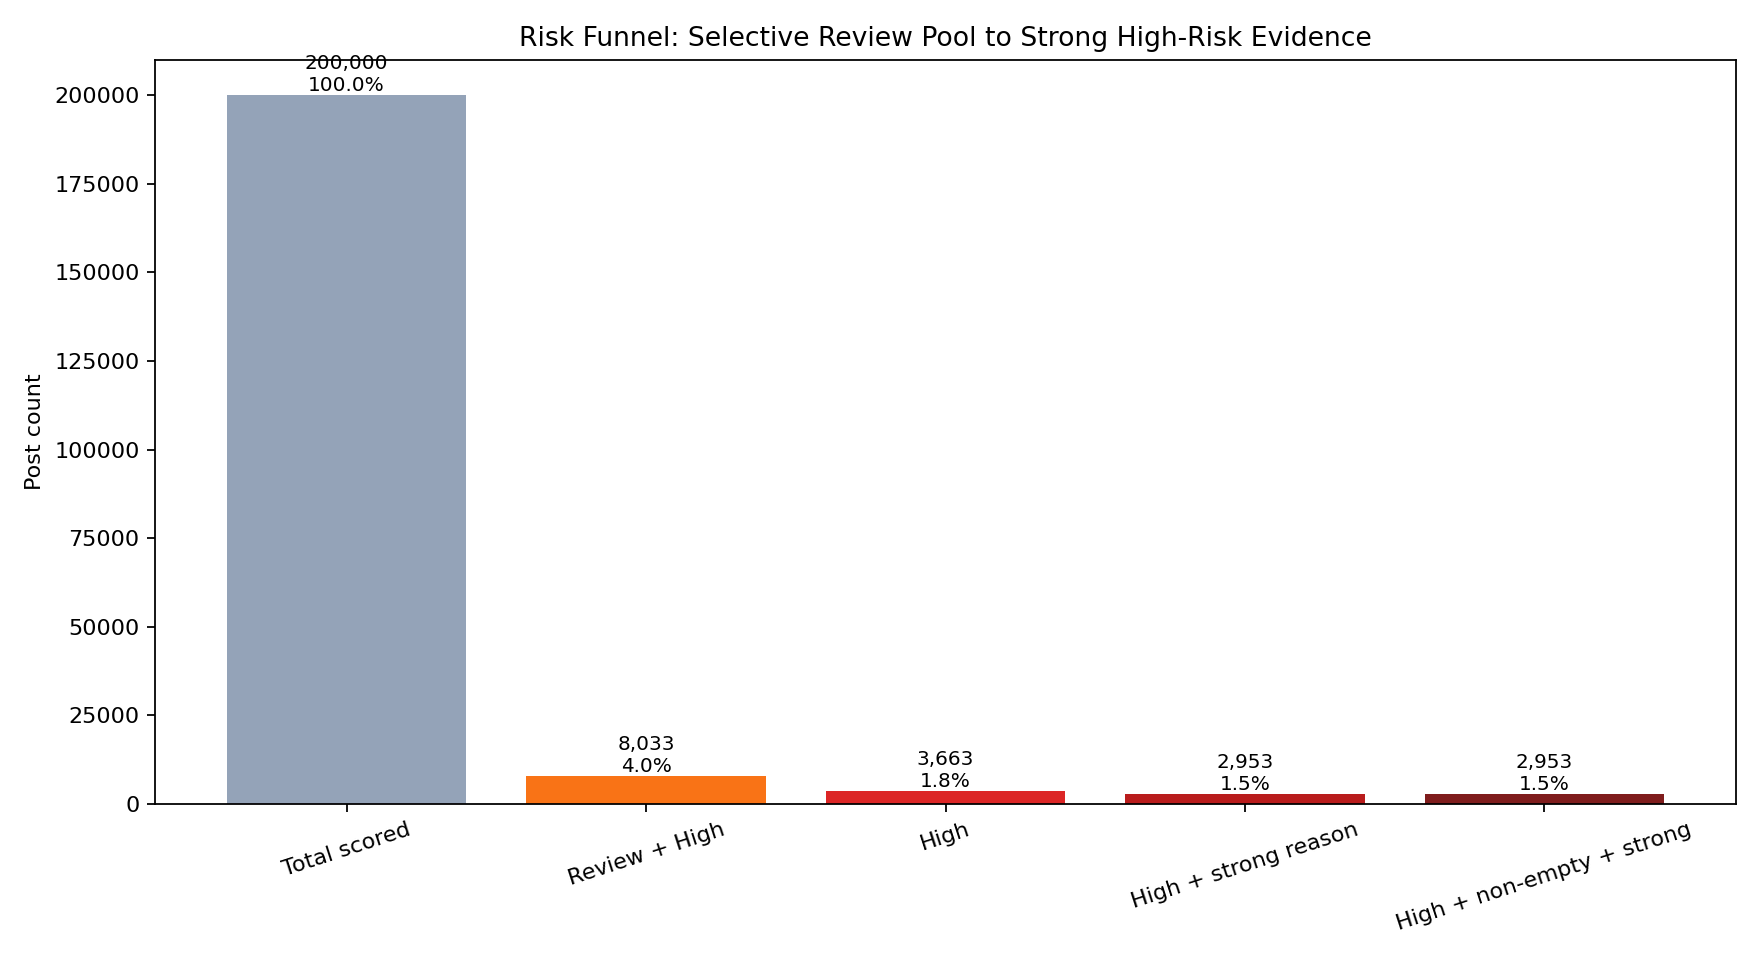

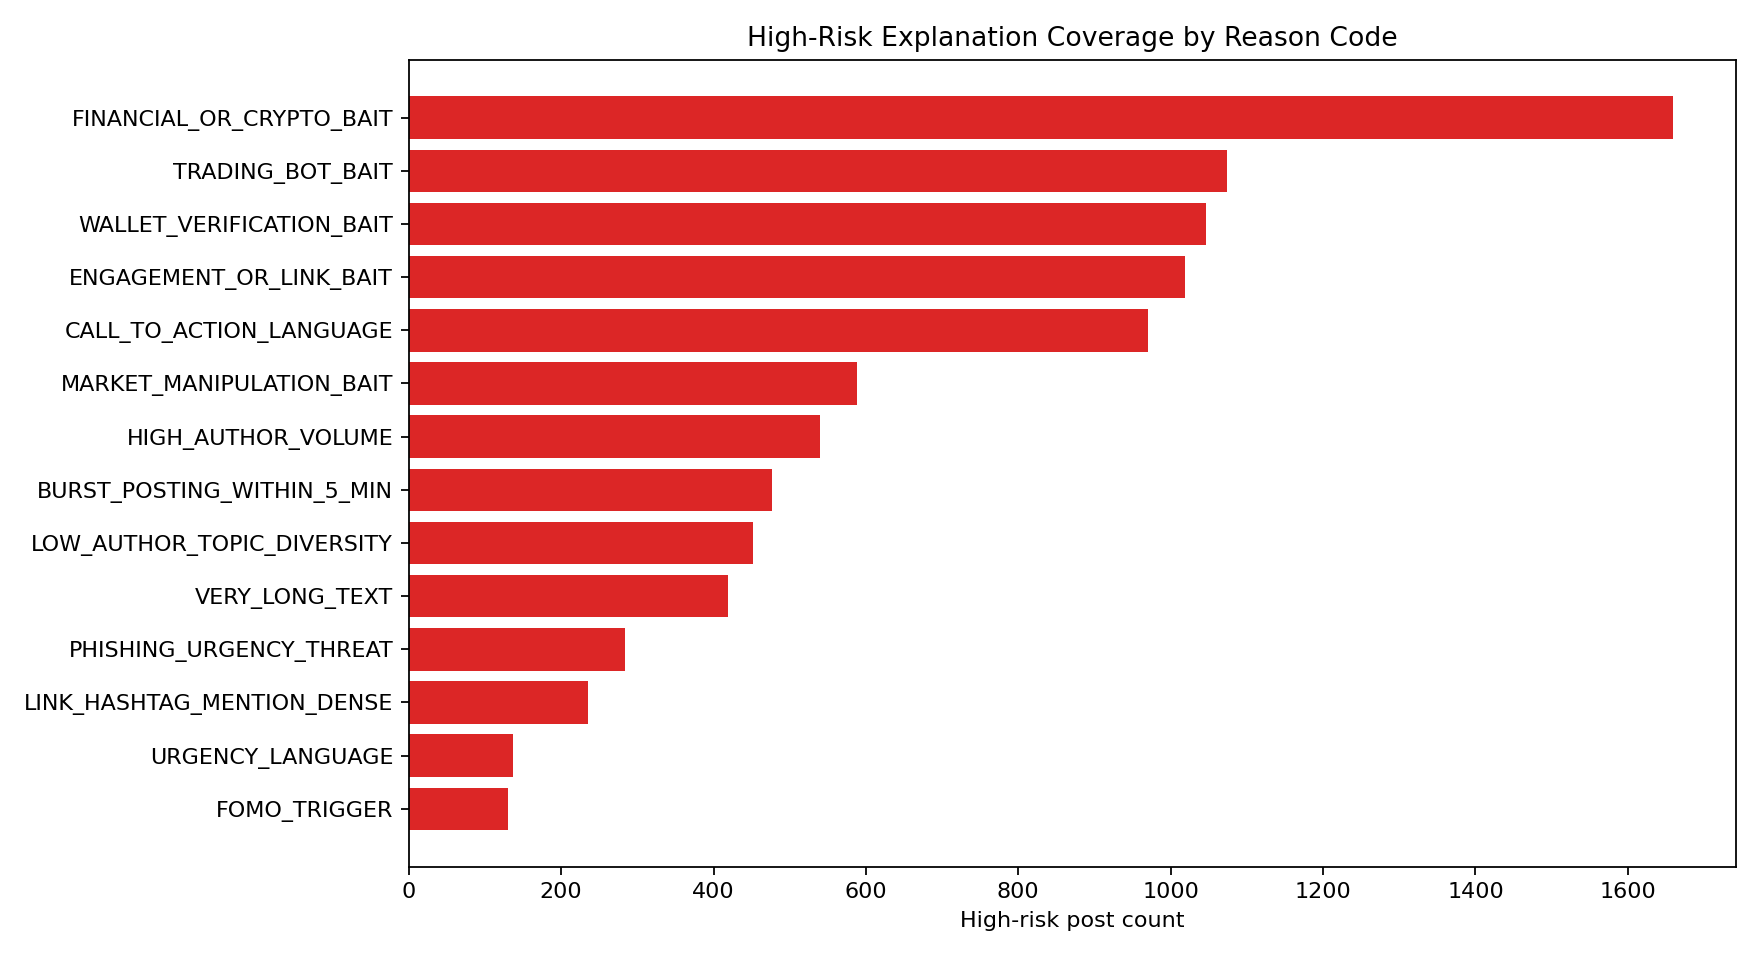

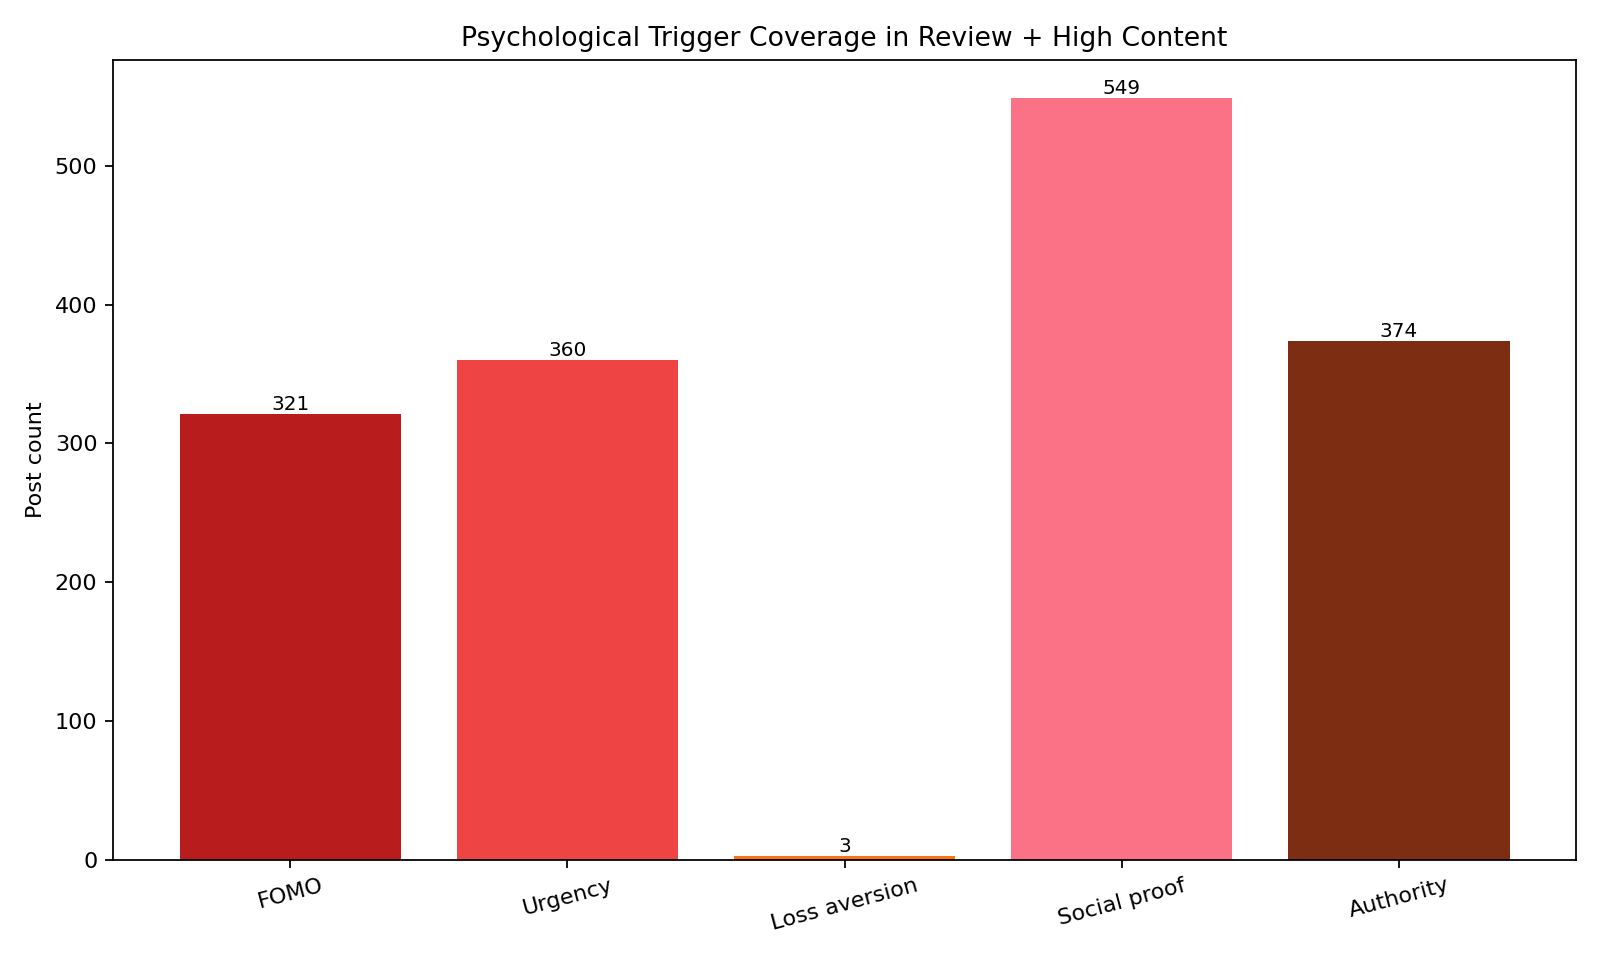

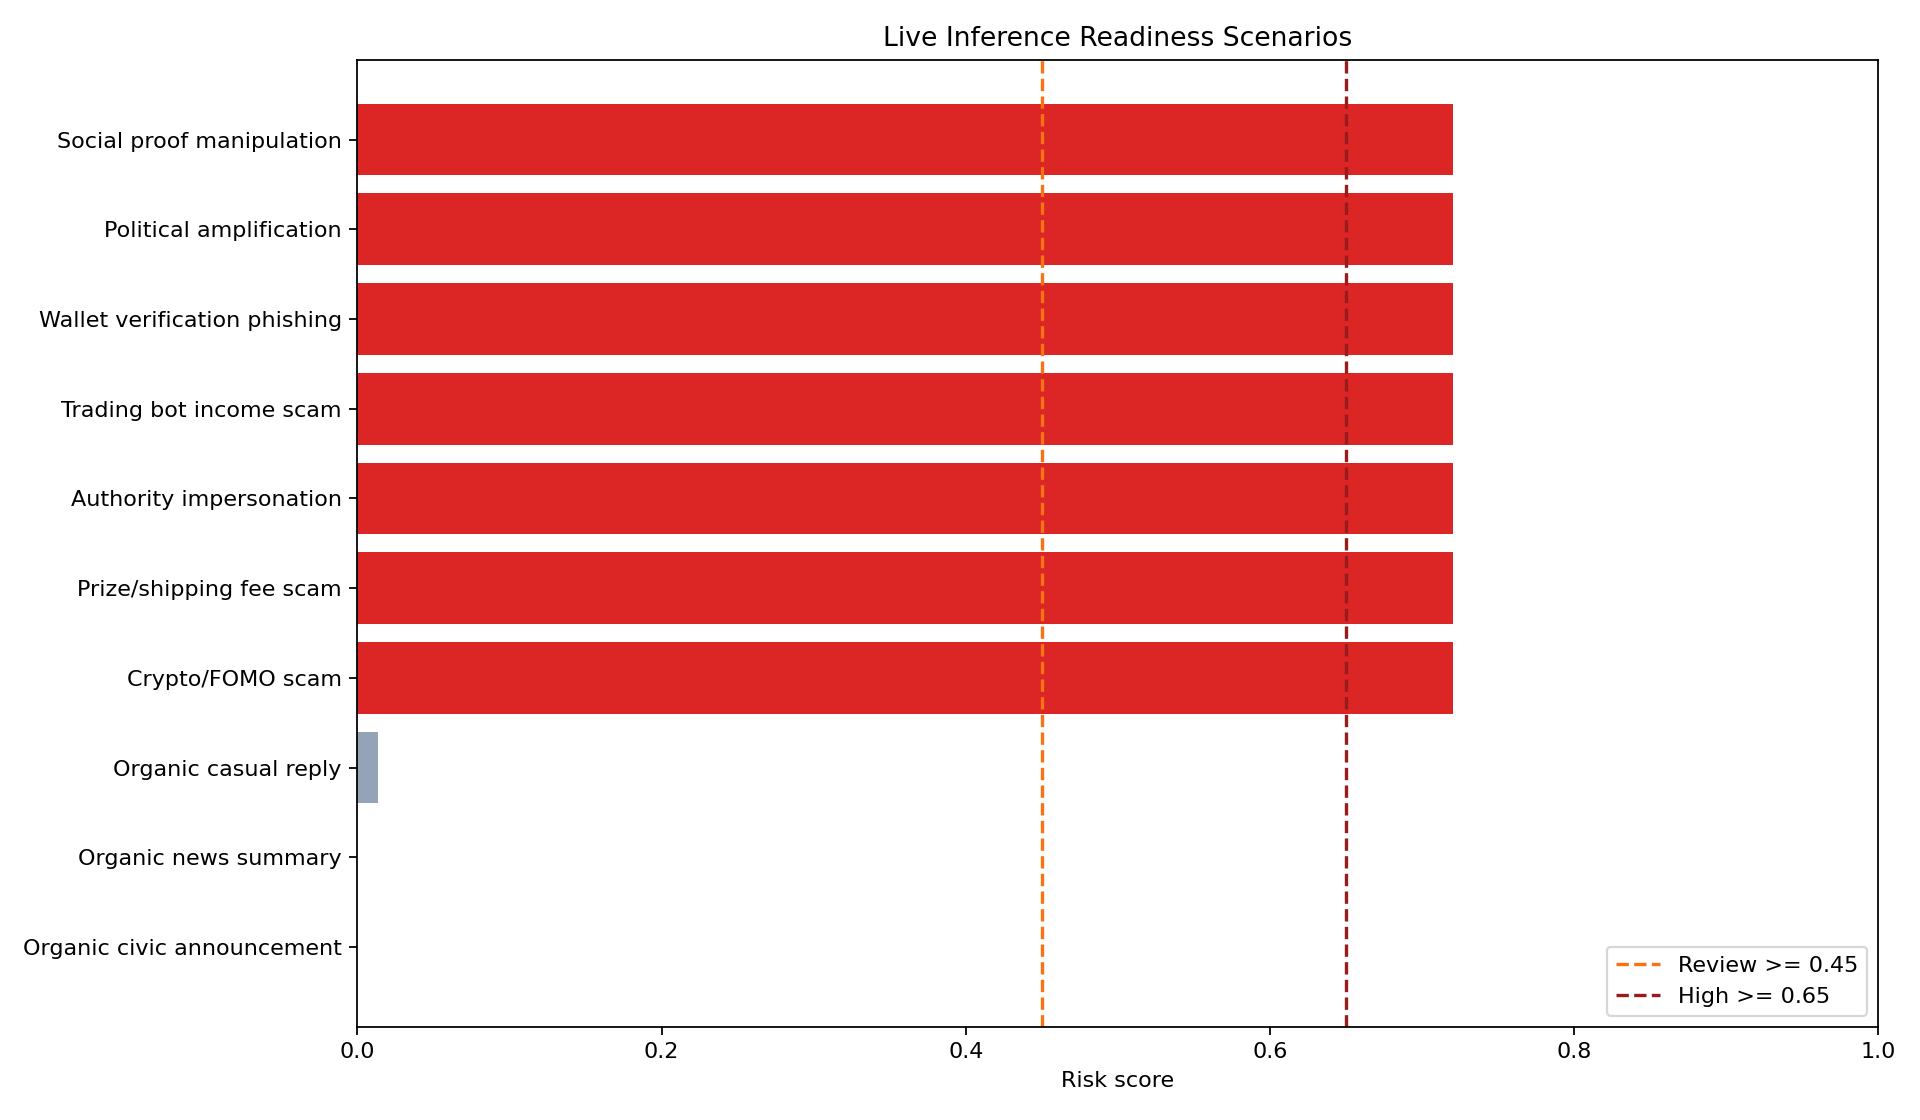

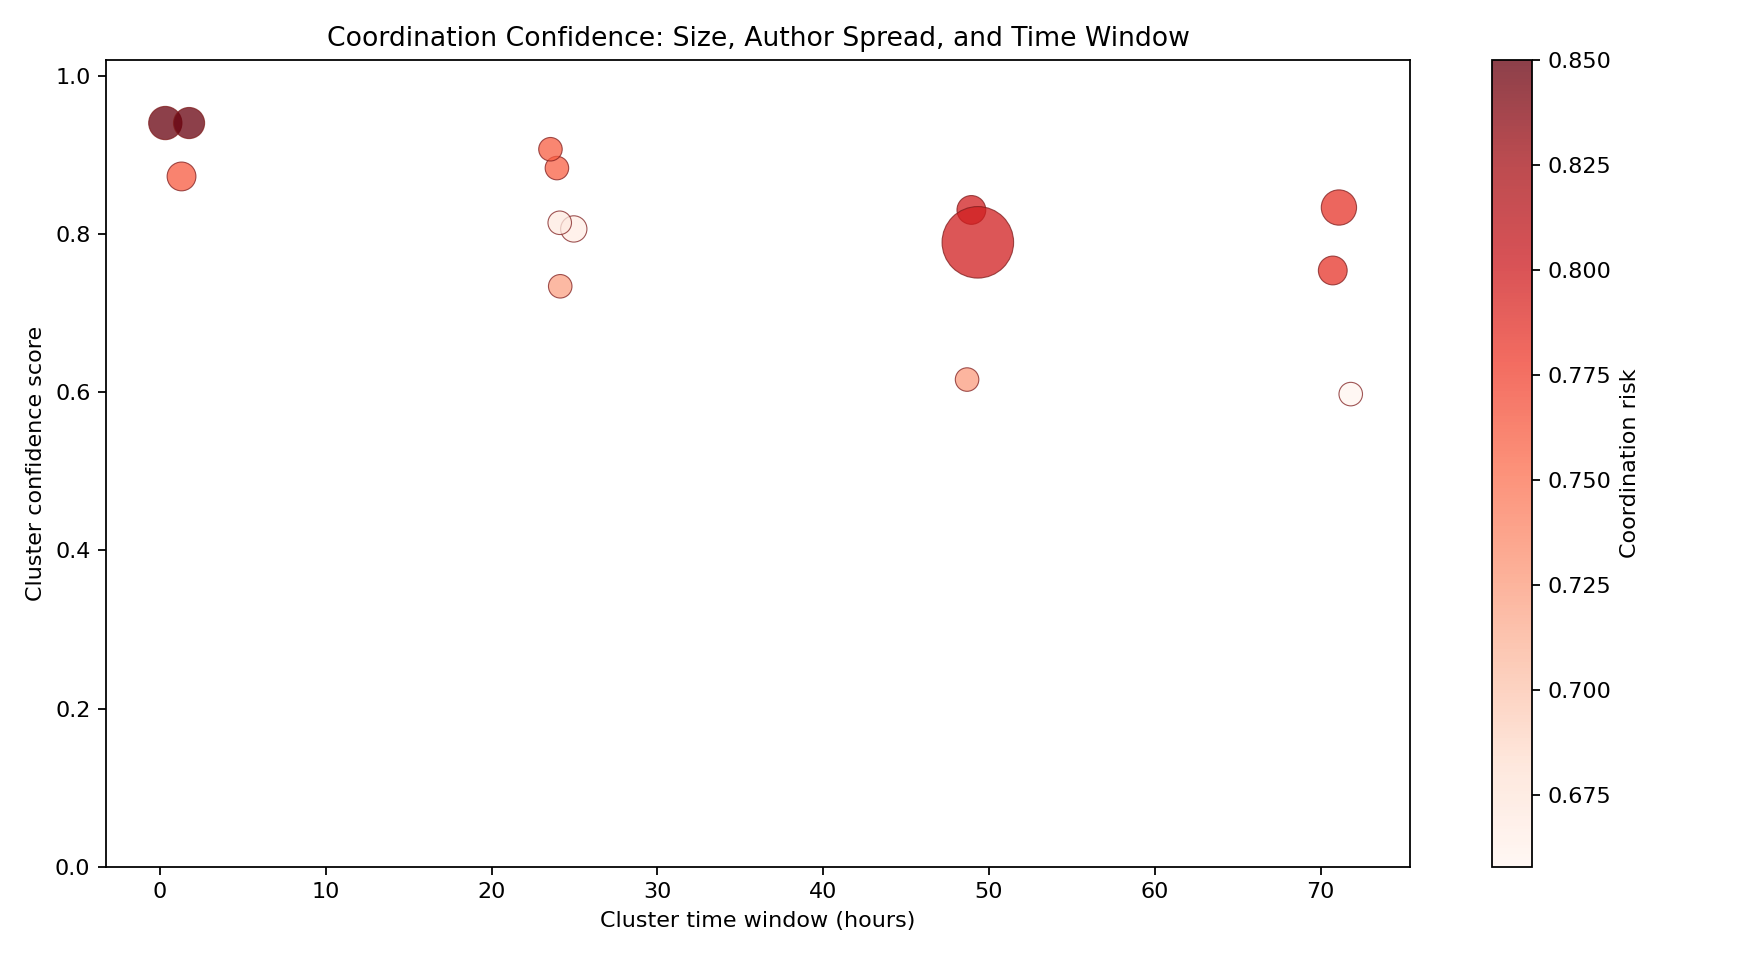

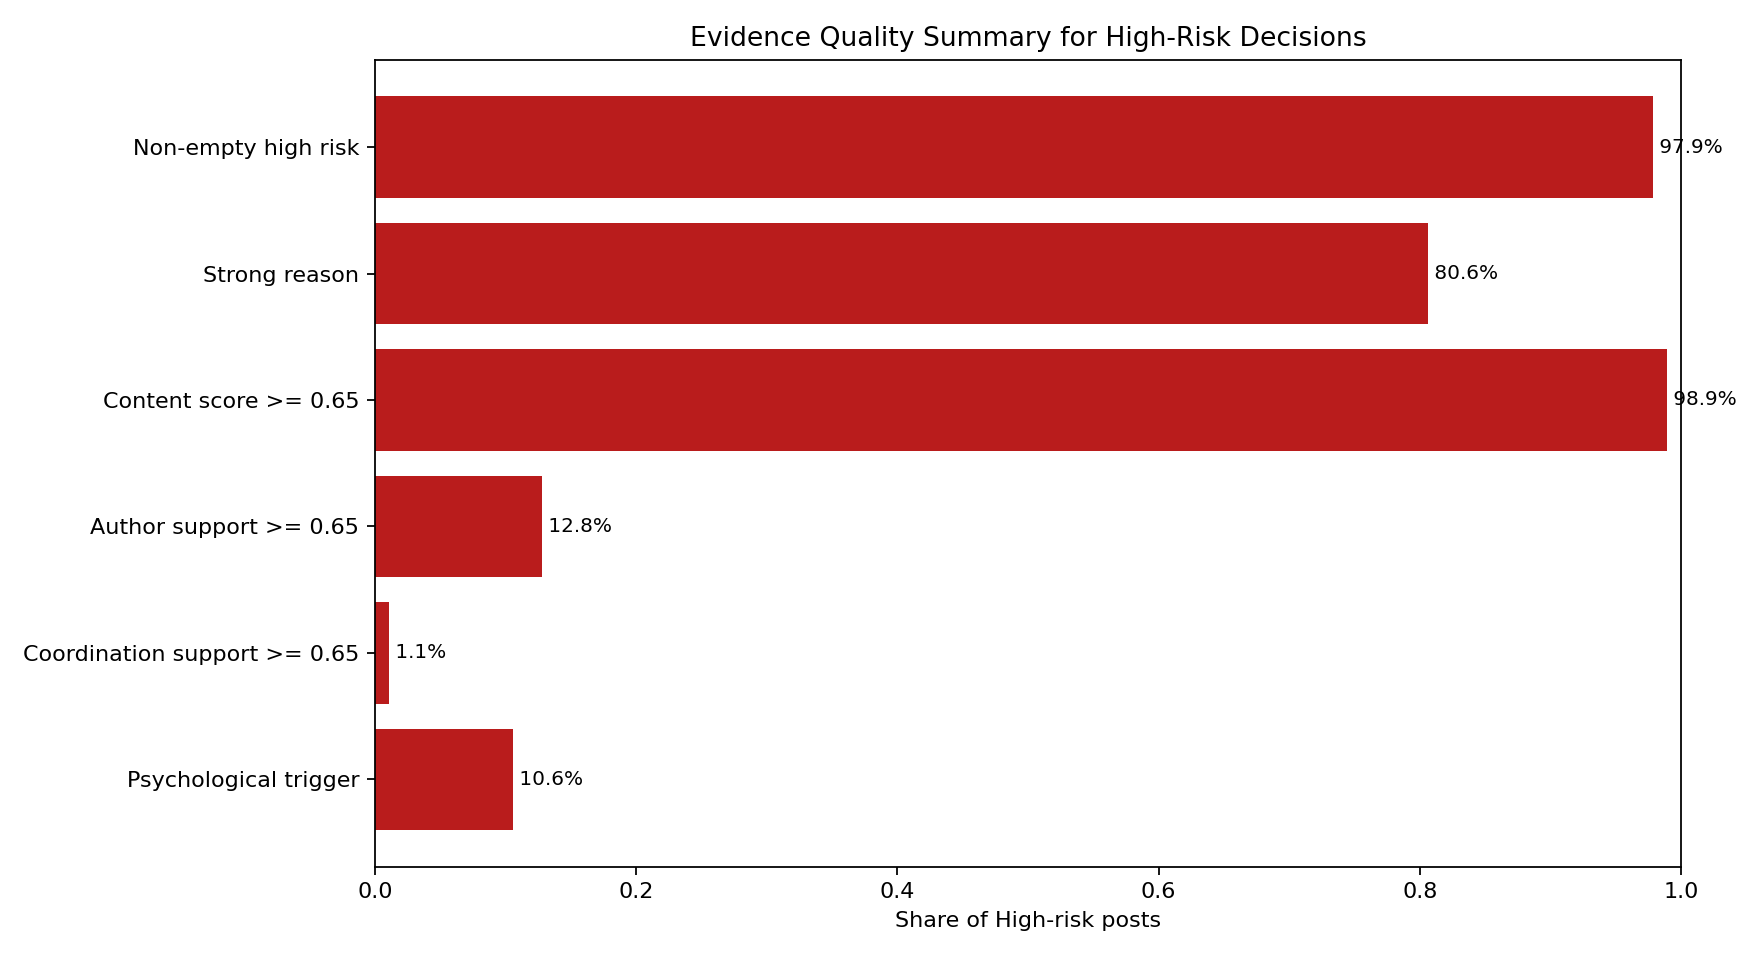

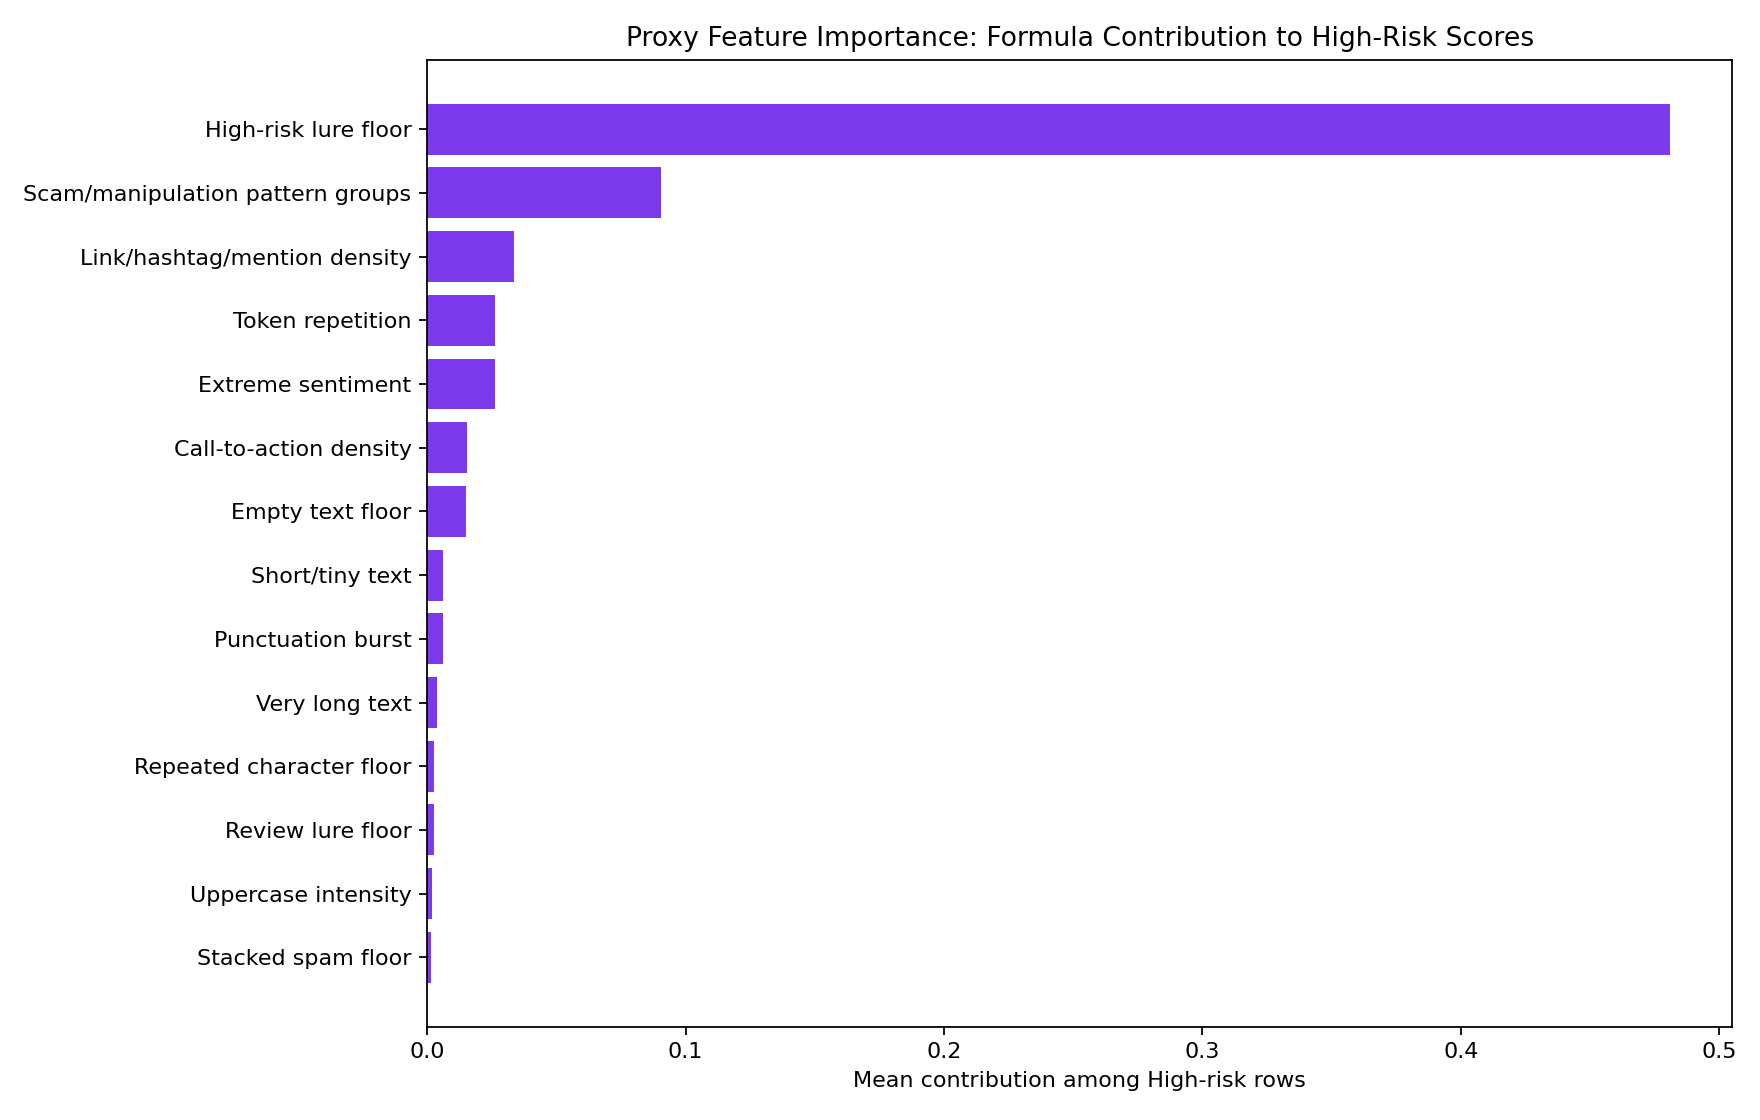

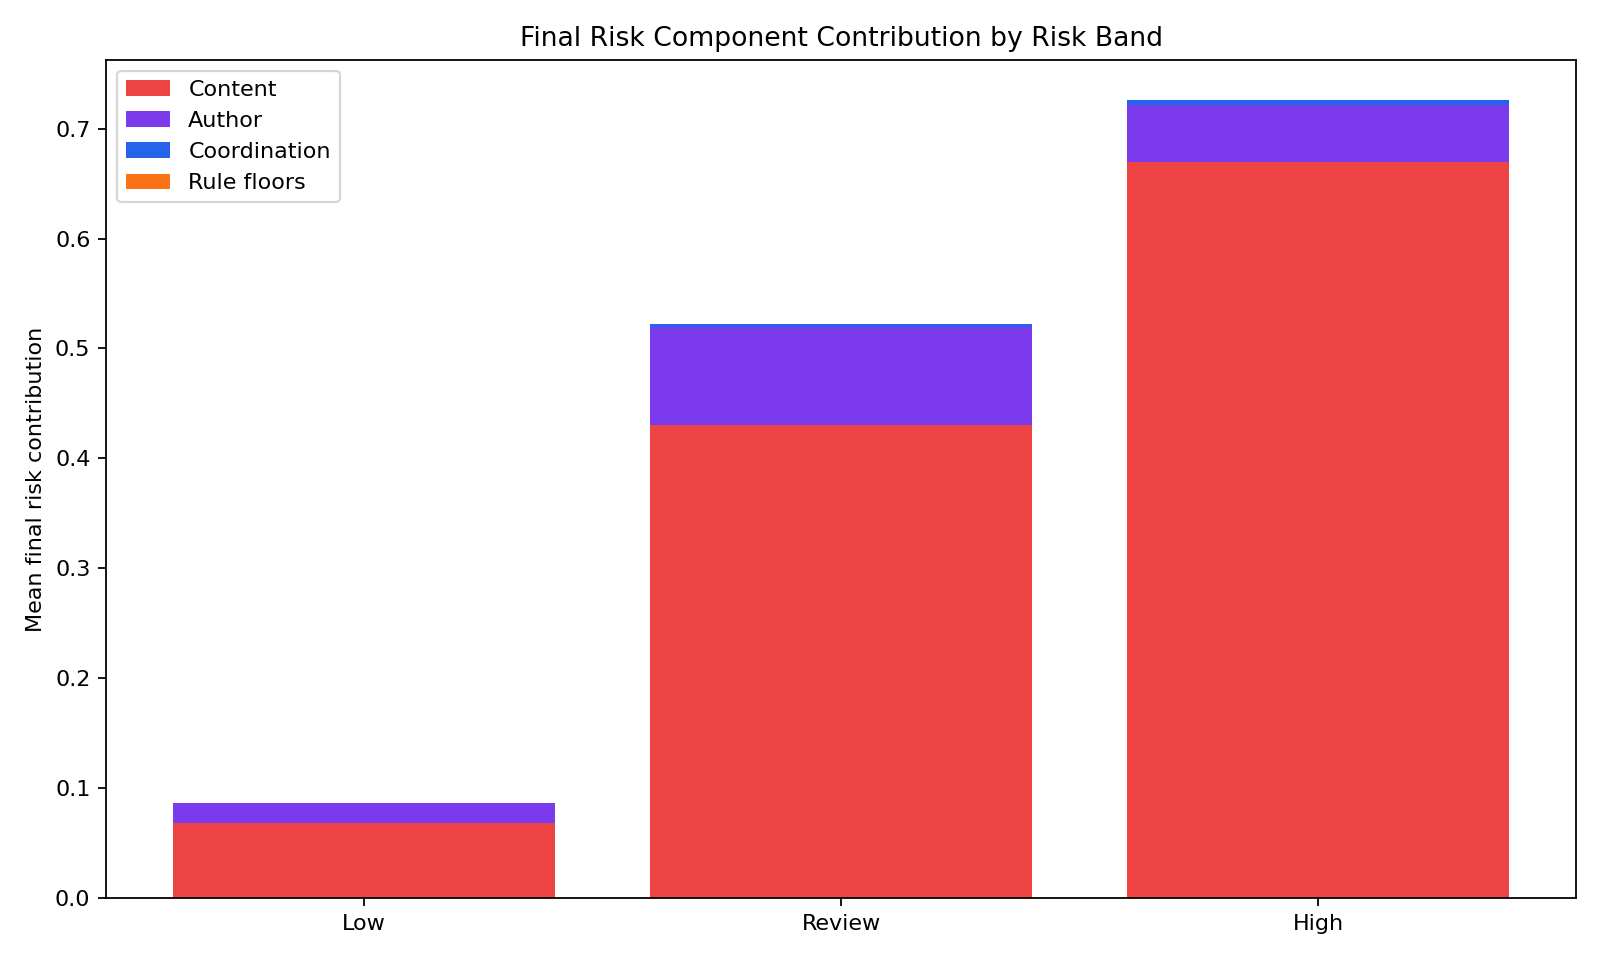

live_inference_benchmark.csv


,category,expected_behavior,readiness_check,risk_score,risk_band,label,evidence_level,nlp_text_risk,nlp_model_used,top_reasons,psychological_triggers,text_preview
0,Crypto/FOMO scam,Review/High,True,0.7200,High,Manipulative,text_only,0.7225,True,FINANCIAL_OR_CRYPTO_BAIT;URGENCY_LANGUAGE;FOMO...,fomo_trigger;urgency_bait,Presale ends in the next 15 minutes. This cryp...
1,Wallet verification phishing,Review/High,True,0.7200,High,Manipulative,text_only,0.7440,True,CALL_TO_ACTION_LANGUAGE;PHISHING_URGENCY_THREA...,urgency_bait;authority_impersonation,Official Meta support requires wallet verifica...
2,Trading bot income scam,Review/High,True,0.7200,High,Manipulative,text_only,0.7392,True,CALL_TO_ACTION_LANGUAGE;FINANCIAL_OR_CRYPTO_BA...,NaN,"Just made $10,000 in one week using this tradi..."
3,Prize/shipping fee scam,Review/High,True,0.7200,High,Manipulative,text_only,0.7345,True,CALL_TO_ACTION_LANGUAGE;ENGAGEMENT_OR_LINK_BAI...,NaN,"Congratulations, you won a $1,000 gift card. P..."
4,Authority impersonation,Review/High,True,0.7200,High,Manipulative,text_only,0.6945,True,PHISHING_URGENCY_THREAT;AUTHORITY_IMPERSONATIO...,authority_impersonation,Platform support team detected suspicious acti...
5,Social proof manipulation,Review/High,True,0.7200,High,Manipulative,text_only,0.7022,True,CALL_TO_ACTION_LANGUAGE;FINANCIAL_OR_CRYPTO_BA...,urgency_bait;social_proof_trigger,"Trusted by 50,000 users. Everyone is joining o..."
6,Political amplification,Review/High,True,0.7200,High,Manipulative,text_only,0.6540,True,CALL_TO_ACTION_LANGUAGE;ENGAGEMENT_OR_LINK_BAI...,urgency_bait,Everyone needs to see this video right now. Vo...
7,Organic civic announcement,Low,True,0.0000,Low,Organic,text_only,NaN,True,LOW_CONTENT_RISK;TEXT_ONLY_METADATA_UNAVAILABLE,NaN,The city council published meeting notes and i...
8,Organic casual reply,Low,True,0.0133,Low,Organic,text_only,NaN,True,LOW_CONTENT_RISK;TEXT_ONLY_METADATA_UNAVAILABLE,NaN,Thanks for sharing the photos from the event. ...
9,Organic news summary,Low,True,0.0000,Low,Organic,text_only,NaN,True,LOW_CONTENT_RISK;TEXT_ONLY_METADATA_UNAVAILABLE,NaN,The report summarizes quarterly public transpo...


presentation_examples.csv


,risk_score,presentation_priority,risk_band,organic_score,label,reason_codes,content_risk,author_risk,coordination_risk,language,...,cluster_size,cluster_author_nunique,cluster_platform_nunique,cluster_window_hours,signature_term_count,cluster_confidence_score,cluster_content_similarity,stripped_char_len,english_keywords,original_text_preview
0,0.787692,0.787692,High,0.212308,Manipulative,LINK_HASHTAG_MENTION_DENSE;CALL_TO_ACTION_LANG...,0.72,0.866667,0.0,en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,209.0,"signal everyday, telegram, channel, forex sign...",Free 3 to 5 signals available everyday in my c...
1,0.787692,0.787692,High,0.212308,Manipulative,LINK_HASHTAG_MENTION_DENSE;CALL_TO_ACTION_LANG...,0.72,0.866667,0.0,en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,209.0,"xauusd, telegram, accuracy, channel telegram, ...",Free 3 to 5 signals available everyday in my c...
2,0.787692,0.787692,High,0.212308,Manipulative,LINK_HASHTAG_MENTION_DENSE;CALL_TO_ACTION_LANG...,0.72,0.866667,0.0,en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,209.0,"forex signal, free, telegram, signal everyday,...",Free 3 to 5 signals available everyday in my c...
3,0.766952,0.766952,High,0.233048,Manipulative,FINANCIAL_OR_CRYPTO_BAIT;ENGAGEMENT_OR_LINK_BA...,0.72,0.821730,0.0,en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,310.0,"spam, message, SPAM, REPORT, report, **report,...","**REPORT posts/comments if they are SPAM, self..."
4,0.766952,0.766952,High,0.233048,Manipulative,VERY_LONG_TEXT;HIGH_TOKEN_REPETITION;LINK_HASH...,0.72,0.821730,0.0,en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1229.0,"week, FAAQ, watch orders, time, orders, restri...",Hello! If you ever find yourself needing anime...
5,0.766952,0.766952,High,0.233048,Manipulative,CALL_TO_ACTION_LANGUAGE;FINANCIAL_OR_CRYPTO_BA...,0.72,0.821730,0.0,en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,700.0,"social media, read, rules, bans, forbidden, po...",--- \n\n&gt;This is a friendly reminder t...
6,0.766952,0.766952,High,0.233048,Manipulative,VERY_LONG_TEXT;FINANCIAL_OR_CRYPTO_BAIT;ENGAGE...,0.72,0.821730,0.0,en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,917.0,"podcast, report, [SUPPORT, thedeprogram, PATRE...",☭☭☭ [SUBSCRIBE TO THE BOIS ON YOUTUBE](https:/...
7,0.766952,0.766952,High,0.233048,Manipulative,VERY_LONG_TEXT;FINANCIAL_OR_CRYPTO_BAIT;TRADIN...,0.72,0.821730,0.0,en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,733.0,"compose, apply, bot, automatically, comment, m...",###[Meta] Sticky Comment\n\n[Rule 2](https://w...
8,0.766952,0.766952,High,0.233048,Manipulative,VERY_LONG_TEXT;FINANCIAL_OR_CRYPTO_BAIT;ENGAGE...,0.72,0.821730,0.0,en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,720.0,"safety settings, max, posts, experiencing, due...","Hi, we are currently experiencing longer than ..."
9,0.766952,0.766952,High,0.233048,Manipulative,VERY_LONG_TEXT;LINK_HASHTAG_MENTION_DENSE;FINA...,0.72,0.821730,0.0,en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,744.0,"freund, das video, klik, video, automatically,...",Du willst das Video runterladen? Klick hier m1...


feature_contribution_summary.csv


,family,feature,contribution_type,active_rows,active_share,mean_contribution_all,mean_contribution_review_high,mean_contribution_high,total_contribution,explanation
0,Content floor,High-risk lure floor,rule floor lift,4315,0.021575,0.010908,0.248552,0.481012,2181.597001,"Phishing, wallet verification, trading bot, fi..."
1,Content,Scam/manipulation pattern groups,weighted additive,16769,0.083845,0.005353,0.059996,0.090363,1070.700000,"Finance, phishing, prize, urgency, FOMO, autho..."
2,Content,Link/hashtag/mention density,weighted additive,27240,0.136200,0.013737,0.027106,0.033655,2747.386370,"Dense external-link, hashtag, or mention usage."
3,Content,Token repetition,weighted additive,132040,0.660200,0.017172,0.023640,0.026400,3434.335305,Repeated tokens or one dominant token.
4,Content,Extreme sentiment,weighted additive,197951,0.989755,0.024534,0.025449,0.026266,4906.865662,Very high absolute sentiment value from datase...
5,Content,Call-to-action density,weighted additive,19190,0.095950,0.001652,0.010051,0.015558,330.382633,"Click, join, follow, DM, buy, and similar acti..."
6,Content floor,Empty text floor,rule floor lift,153,0.000765,0.000546,0.013582,0.015187,109.103896,Empty/whitespace-only text is treated as a dat...
7,Content,Short/tiny text,weighted additive,15890,0.079450,0.006105,0.006316,0.006190,1220.966667,Very short text base signal; calibrated so non...
8,Content,Punctuation burst,weighted additive,48330,0.241650,0.005976,0.005919,0.006127,1195.188216,Excessive punctuation such as !!! or ???.
9,Content,Very long text,weighted additive,3394,0.016970,0.000549,0.004303,0.003934,109.773000,Extremely long text can indicate copied/promot...


risk_component_contribution_summary.csv


,family,feature,contribution_type,active_rows,active_share,mean_contribution_all,mean_contribution_review_high,mean_contribution_high,total_contribution,explanation
0,Final risk component,Content component,normalized weighted component,199546,0.997730,8.751678e-02,0.539257,0.669343,17503.356570,Content-risk contribution after metadata avail...
1,Final risk component,Author component,normalized weighted component,32061,0.160305,2.003613e-02,0.072656,0.052477,4007.226223,Author behavior contribution when enough autho...
2,Final risk component,Coordination component,normalized weighted component,108,0.000540,1.754911e-04,0.002872,0.003766,35.098226,Narrative cluster contribution when coordinati...
3,Final risk floor,High coordination floor,rule floor lift,15,0.000075,9.008449e-06,0.000224,0.000492,1.801690,Coordination risk >= 0.80 lifts final risk to ...
4,Final risk floor,Coordination + content floor,rule floor lift,13,0.000065,4.461807e-06,0.000111,0.000244,0.892361,Coordination risk >= 0.65 with content support...
5,Final risk floor,Author + support floor,rule floor lift,5,0.000025,2.877304e-07,0.000007,0.000016,0.057546,High author risk with content or coordination ...


In [7]:
from IPython.display import Image, Markdown, display

scorecard_path = ARTIFACT_DIR / "marketing_scorecard.md"
if scorecard_path.exists():
    display(Markdown(scorecard_path.read_text(encoding="utf-8")))

for image_name in [
    "risk_funnel.png",
    "reason_code_breakdown.png",
    "psychological_trigger_breakdown.png",
    "live_inference_benchmark.png",
    "coordination_confidence_bubble.png",
    "evidence_quality_summary.png",
    "feature_importance_proxy.png",
    "risk_component_contribution.png",
]:
    path = ARTIFACT_DIR / image_name
    if path.exists():
        display(Image(filename=str(path)))

for table_name in ["live_inference_benchmark.csv", "presentation_examples.csv", "feature_contribution_summary.csv", "risk_component_contribution_summary.csv"]:
    path = ARTIFACT_DIR / table_name
    if path.exists():
        print(table_name)
        display(pd.read_csv(path).head(10))

## 6. Live Inference Demo

In [8]:
import importlib
import datathon_pipeline as dp
dp = importlib.reload(dp)
predict_live = dp.predict_live
load_context = dp.load_context
context = load_context(ARTIFACT_DIR)
print("Pipeline version:", dp.MODEL_VERSION)
print("Loaded fresh inference context from artifacts.")

demo_texts = [
    "The city council published meeting notes and invited residents to comment.",
    "BUY NOW!!! FREE FREE FREE #deal #promo https://spam.example.com",
    "",
]

for text in demo_texts:
    print("TEXT:", repr(text))
    print(predict_live(text, context=context))
    print("-" * 80)

Pipeline version: text-calibration-v6-credential-finance-patterns
Loaded fresh inference context from artifacts.
TEXT: 'The city council published meeting notes and invited residents to comment.'
{'model_version': 'text-calibration-v6-credential-finance-patterns', 'label': 'Organic', 'risk_score': 0.0, 'risk_band': 'Low', 'organic_score': 1.0, 'evidence_level': 'text_only', 'nlp_text_risk': None, 'nlp_model_used': True, 'top_reasons': ['LOW_CONTENT_RISK', 'TEXT_ONLY_METADATA_UNAVAILABLE'], 'used_features': {'content_risk': 0.0, 'nlp_text_risk': None, 'nlp_raw_text_risk': 0.6852, 'nlp_model_used': True, 'nlp_support_allowed': False, 'author_risk': None, 'coordination_risk': None, 'narrative_signature': 'tx:city|comment|council|invited|meeting|notes|published|residents', 'text_features': {'char_len': 74.0, 'word_count': 11.0, 'repetition_ratio': 0.0, 'link_signal_density': 0.0, 'uppercase_ratio': 0.015873015873015872, 'punctuation_density': 0.0, 'call_to_action_count': 0.0, 'scam_signal_

## 7. Jury Input Cell

Paste the hidden test text below during the presentation.

In [9]:
import importlib
import datathon_pipeline as dp
dp = importlib.reload(dp)
predict_live = dp.predict_live
load_context = dp.load_context
context = load_context(ARTIFACT_DIR)
print("Pipeline version:", dp.MODEL_VERSION)
print("Loaded fresh inference context from artifacts.")

hidden_text = "PASTE JURY TEXT HERE"
predict_live(hidden_text, context=context)

Pipeline version: text-calibration-v6-credential-finance-patterns
Loaded fresh inference context from artifacts.


{'model_version': 'text-calibration-v6-credential-finance-patterns',
 'label': 'Organic',
 'risk_score': 0.1533,
 'risk_band': 'Low',
 'organic_score': 0.8467,
 'evidence_level': 'text_only',
 'nlp_text_risk': 0.6257,
 'nlp_model_used': True,
 'top_reasons': ['VERY_SHORT_TEXT', 'TEXT_ONLY_METADATA_UNAVAILABLE'],
 'used_features': {'content_risk': 0.1533,
  'nlp_text_risk': 0.6257,
  'nlp_raw_text_risk': 0.6257,
  'nlp_model_used': True,
  'nlp_support_allowed': True,
  'author_risk': None,
  'coordination_risk': None,
  'narrative_signature': 'tx:here|jury|paste|text',
  'text_features': {'char_len': 20.0,
   'word_count': 4.0,
   'repetition_ratio': 0.0,
   'link_signal_density': 0.0,
   'uppercase_ratio': 1.0,
   'punctuation_density': 0.0,
   'call_to_action_count': 0.0,
   'scam_signal_count': 0.0,
   'scam_signal_groups': 0.0,
   'url_only_or_link_only': 0.0},
  'psychological_triggers': {'fomo_trigger': 0,
   'urgency_bait': 0,
   'loss_aversion_trigger': 0,
   'social_proof_trig

## 8. Jury CSV Batch Inference

Put the CSV file from the jury into `jury_inputs/`. In the next cell, change only `JURY_CSV_FILENAME` to the file name. The predictions will be written under `artifacts/`.

Input CSV: jury_inputs/YARISMACI_TEST_GIRDISI.csv
Submission CSV: artifacts/jury_predictions_YARISMACI_TEST_GIRDISI.csv
Detailed CSV: artifacts/jury_predictions_YARISMACI_TEST_GIRDISI_detailed.csv
Rows/cells scored: 443
Pipeline version: text-calibration-v6-credential-finance-patterns
Summary CSV: artifacts/jury_predictions_YARISMACI_TEST_GIRDISI_summary.csv
Summary Markdown: artifacts/jury_predictions_YARISMACI_TEST_GIRDISI_summary.md
Top risk examples CSV: artifacts/jury_predictions_YARISMACI_TEST_GIRDISI_top_risk_examples.csv


,metric,value
0,Average risk score,0.1863
1,Median risk score,0.1397
2,P90 risk score,0.5
3,Review + High share,13.54%
4,High share,8.13%
5,Manipulative share,8.13%


,risk_band,count,share
0,Low,383,0.8646
1,High,36,0.0813
2,Review,24,0.0542


,test_id,source_row,source_column,risk_score,risk_band,label,evidence_level,top_reasons,psychological_triggers,original_text
0,TEST_0000,1,text,0.7200,High,Manipulative,text_only,CALL_TO_ACTION_LANGUAGE;FINANCIAL_OR_CRYPTO_BA...,,"I got a likely phishing email from ""service@pa..."
1,TEST_0001,2,text,0.0205,Low,Organic,text_only,LOW_CONTENT_RISK;TEXT_ONLY_METADATA_UNAVAILABLE,,It is taking me a bit of time each day to unsu...
2,TEST_0002,3,text,0.0154,Low,Organic,text_only,LOW_CONTENT_RISK;TEXT_ONLY_METADATA_UNAVAILABLE,,Some defy classification. And that is how your...
3,TEST_0003,4,text,0.1854,Low,Organic,text_only,LINK_HASHTAG_MENTION_DENSE;TEXT_ONLY_METADATA_...,,These phishing emails are getting more and mor...
4,TEST_0004,5,text,0.1041,Low,Organic,text_only,LOW_CONTENT_RISK;TEXT_ONLY_METADATA_UNAVAILABLE,,We’re so excited about Apple featuring us amon...
5,TEST_0005,6,text,0.5000,Review,Organic,text_only,LINK_HASHTAG_MENTION_DENSE;ENGAGEMENT_OR_LINK_...,,Detected #phishing clone at address: hxxps://s...
6,TEST_0006,7,text,0.0500,Low,Organic,text_only,LOW_CONTENT_RISK;TEXT_ONLY_METADATA_UNAVAILABLE,,Has Apple had a breach? A fraudulent order for...
7,TEST_0007,8,text,0.1720,Low,Organic,text_only,FINANCIAL_OR_CRYPTO_BAIT;TEXT_ONLY_METADATA_UN...,,I make this clear: I don't associate with anyo...
8,TEST_0008,9,text,0.0383,Low,Organic,text_only,LOW_CONTENT_RISK;TEXT_ONLY_METADATA_UNAVAILABLE,,Two of the most important things you need for ...
9,TEST_0009,10,text,0.0300,Low,Organic,text_only,LOW_CONTENT_RISK;TEXT_ONLY_METADATA_UNAVAILABLE,,"This is what PHISHING means ""the fraudulent pr..."


artifacts/jury_predictions_YARISMACI_TEST_GIRDISI_risk_band_distribution.png


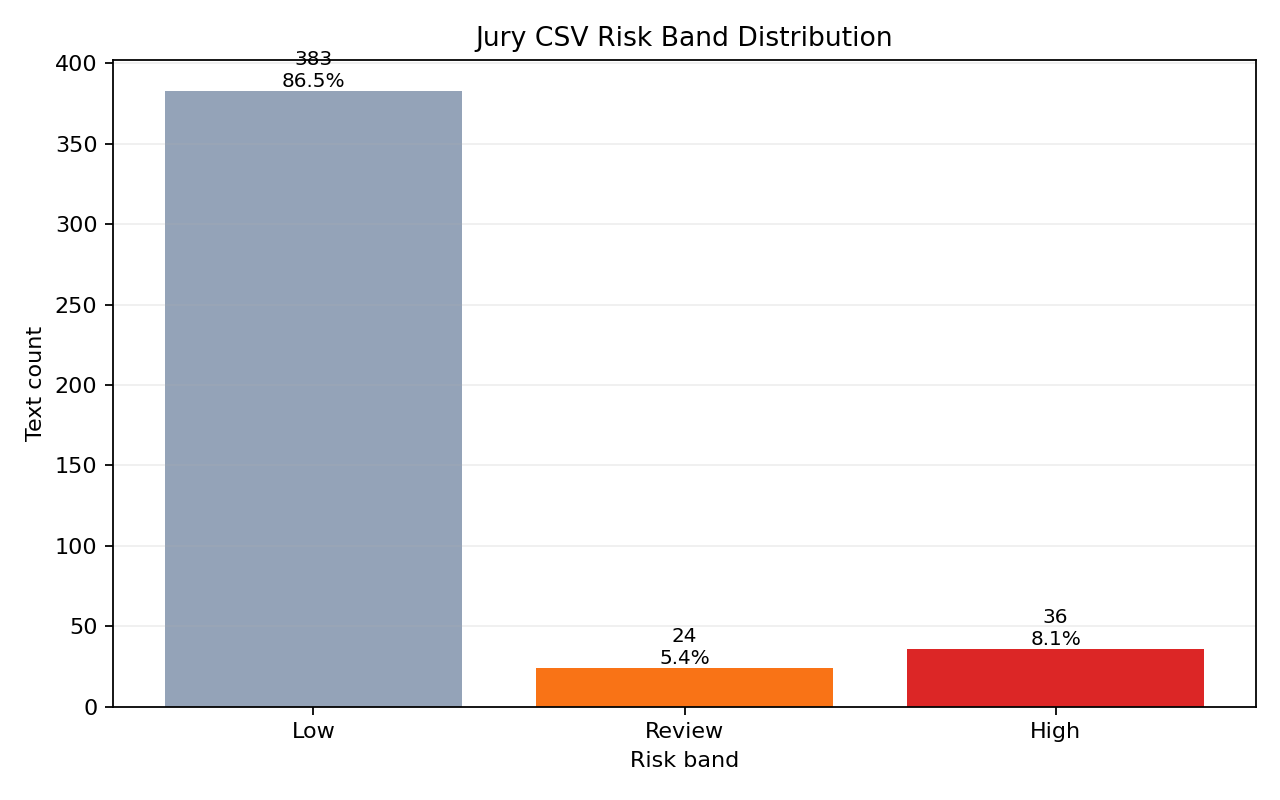

artifacts/jury_predictions_YARISMACI_TEST_GIRDISI_risk_score_histogram.png


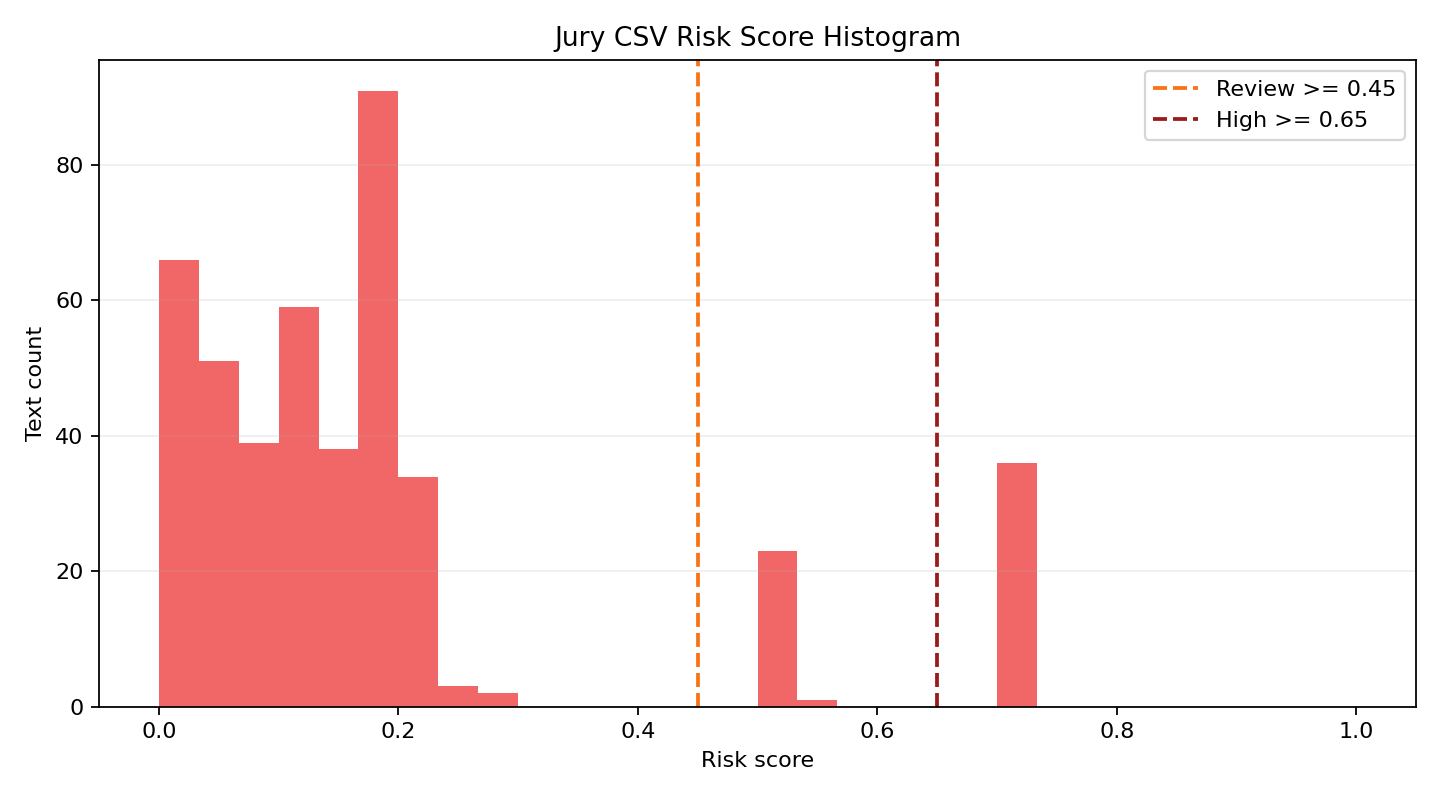

artifacts/jury_predictions_YARISMACI_TEST_GIRDISI_reason_code_breakdown.png


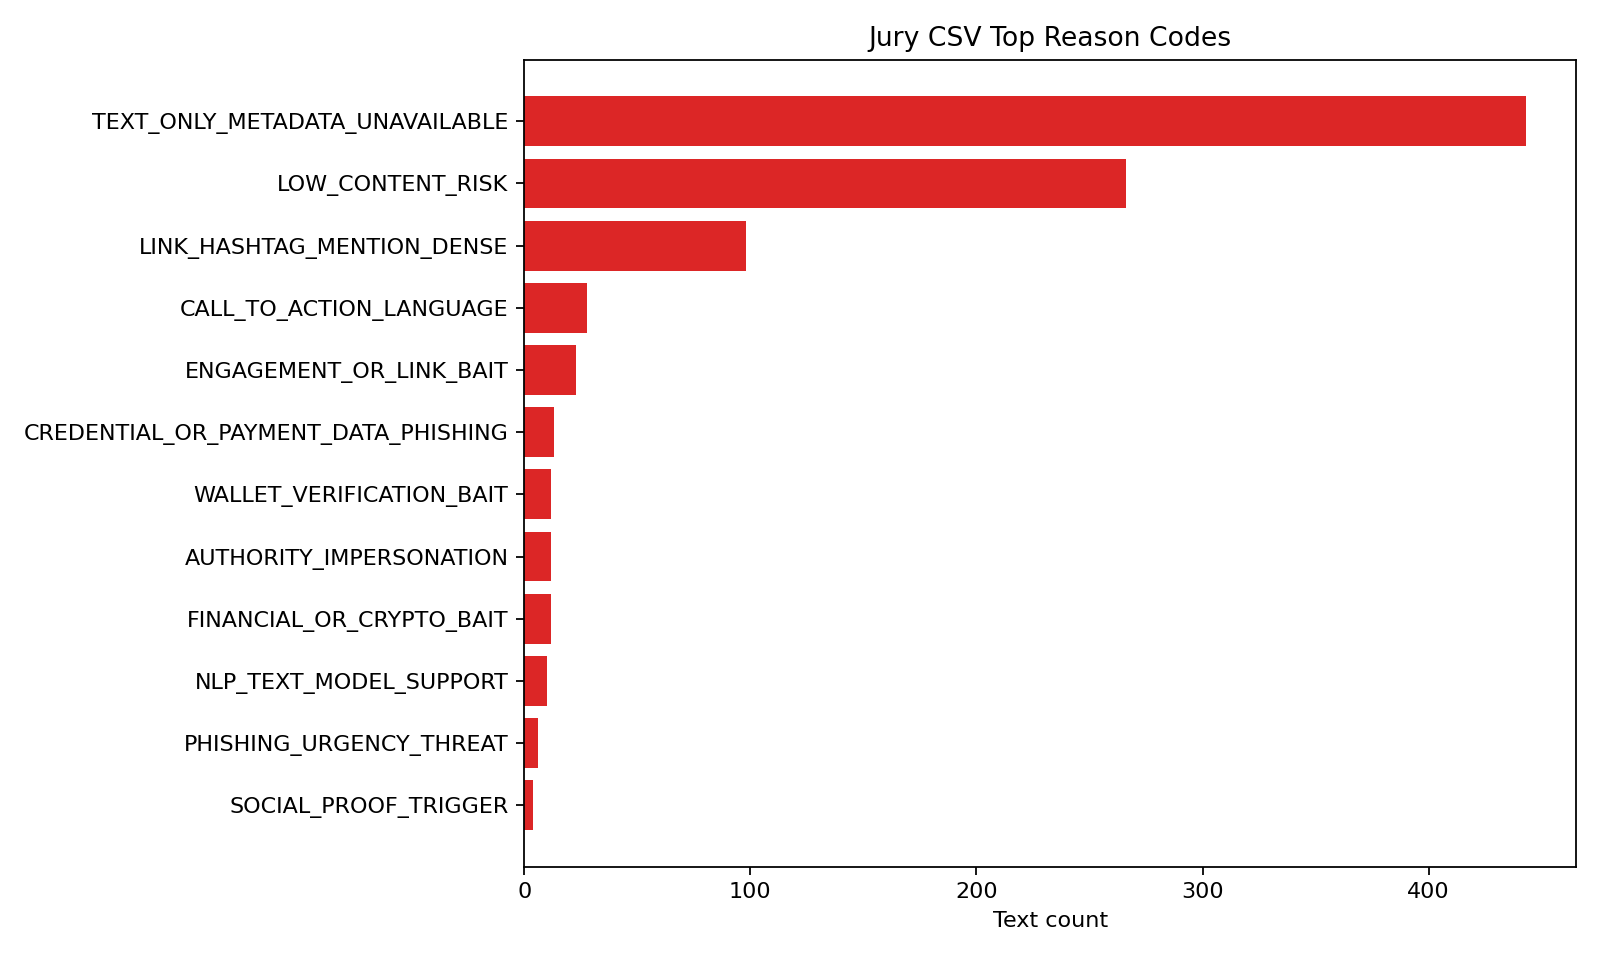

artifacts/jury_predictions_YARISMACI_TEST_GIRDISI_psychological_trigger_breakdown.png


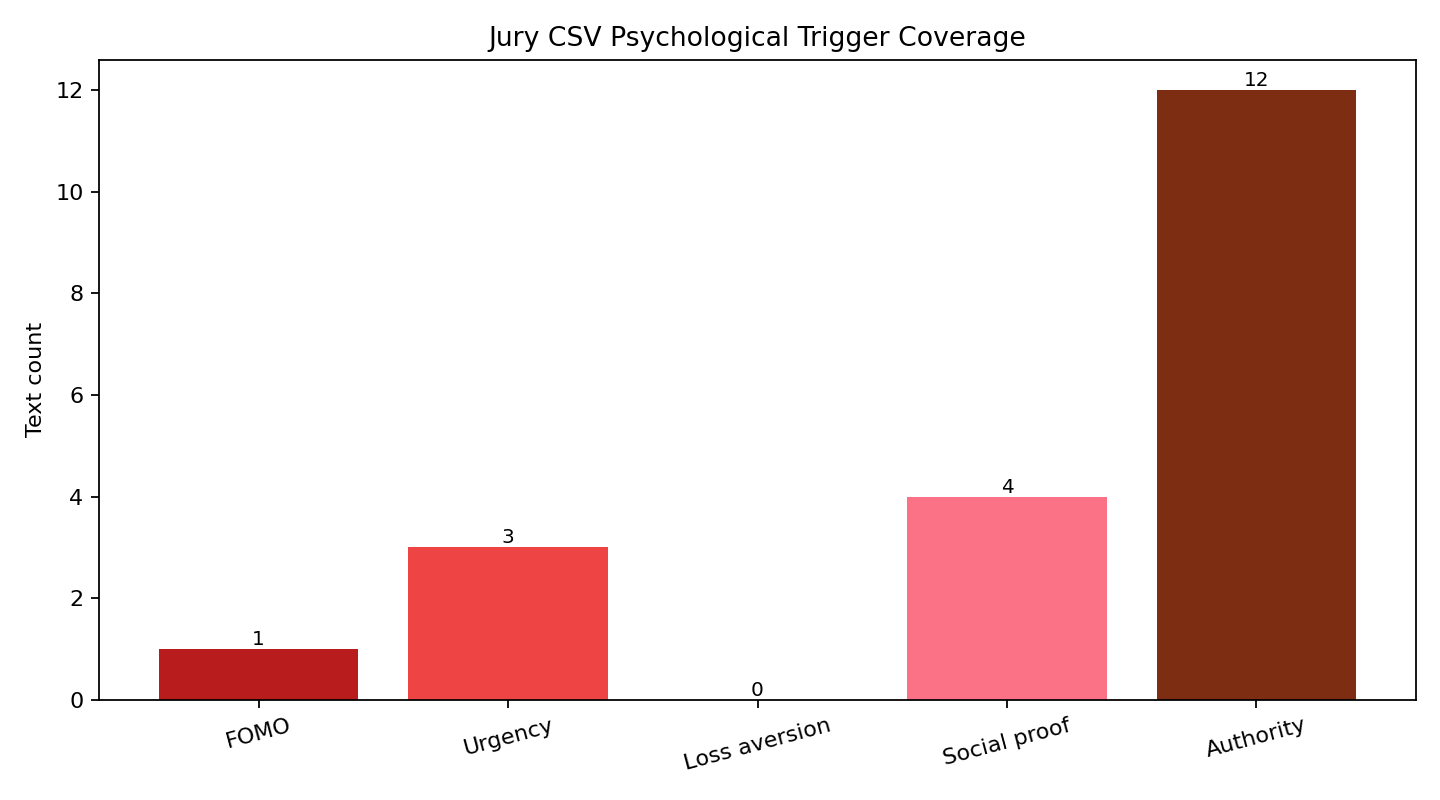

In [10]:
import importlib
from pathlib import Path
import pandas as pd

import datathon_pipeline as dp
dp = importlib.reload(dp)

# 1) Put the jury CSV under this folder.
JURY_INPUT_DIR = Path("jury_inputs")

# 2) During the presentation, change only this file name.
JURY_CSV_FILENAME = "YARISMACI_TEST_GIRDISI.csv"

# Usually leave these defaults as-is.
TEXT_COLUMN = None          # None auto-detects original_text/text or scores all non-metadata columns.
CSV_HAS_HEADER = True       # Set False if the jury CSV has no header row.
CSV_SEPARATOR = ","         # Use ";" for semicolon CSV or "auto" for delimiter sniffing.
USE_ALL_CELLS = False       # Set True if every non-metadata cell may contain a text.

JURY_INPUT_DIR.mkdir(exist_ok=True)
jury_csv_path = JURY_INPUT_DIR / JURY_CSV_FILENAME
if not jury_csv_path.exists():
    raise FileNotFoundError(
        f"CSV not found: {jury_csv_path.resolve()}\n"
        "Put the jury file under jury_inputs/ and update JURY_CSV_FILENAME."
    )

output_path = ARTIFACT_DIR / f"jury_predictions_{jury_csv_path.stem}.csv"
effective_text_column = None if USE_ALL_CELLS else TEXT_COLUMN

predictions, jury_summary = dp.predict_csv_file(
    input_csv=jury_csv_path,
    output_csv=output_path,
    text_column=effective_text_column,
    all_cells=USE_ALL_CELLS,
    no_header=not CSV_HAS_HEADER,
    csv_sep=CSV_SEPARATOR,
    artifacts_dir=ARTIFACT_DIR,
)

print("Input CSV:", jury_csv_path)
print("Submission CSV:", output_path)
print("Detailed CSV:", jury_summary.get("detailed_output_csv"))
print("Rows/cells scored:", jury_summary["texts_scored"])
print("Pipeline version:", dp.MODEL_VERSION)
print("Summary CSV:", jury_summary.get("summary_csv"))
print("Summary Markdown:", jury_summary.get("summary_markdown"))
print("Top risk examples CSV:", jury_summary.get("top_risk_examples_csv"))

summary_overview = pd.DataFrame([
    {"metric": "Average risk score", "value": round(jury_summary.get("risk_score_mean", 0), 4)},
    {"metric": "Median risk score", "value": round(jury_summary.get("risk_score_median", 0), 4)},
    {"metric": "P90 risk score", "value": round(jury_summary.get("risk_score_p90", 0), 4)},
    {"metric": "Review + High share", "value": f"{jury_summary.get('review_high_share', 0):.2%}"},
    {"metric": "High share", "value": f"{jury_summary.get('high_share', 0):.2%}"},
    {"metric": "Manipulative share", "value": f"{jury_summary.get('manipulative_share', 0):.2%}"},
])
display(summary_overview)

band_summary = (
    predictions["risk_band"]
    .value_counts(dropna=False)
    .rename_axis("risk_band")
    .reset_index(name="count")
)
band_summary["share"] = (band_summary["count"] / max(len(predictions), 1)).round(4)
display(band_summary)

preview_cols = [
    "test_id", "source_row", "source_column", "risk_score", "risk_band", "label",
    "evidence_level", "top_reasons", "psychological_triggers", "original_text"
]
display(predictions[[c for c in preview_cols if c in predictions.columns]].head(30))

try:
    from IPython.display import Image
    for plot_path in jury_summary.get("batch_plot_paths", []):
        print(plot_path)
        display(Image(filename=plot_path))
except Exception as exc:
    print("Plot preview skipped:", exc)


In [11]:
import pandas as pd
import numpy as np
from pathlib import Path

try:
    from sklearn.metrics import roc_auc_score, accuracy_score
except ImportError:
    roc_auc_score = None

    def accuracy_score(y_true, y_pred):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        return float((y_true == y_pred).mean())

    def _fallback_roc_auc_score(y_true, y_score):
        y_true = np.asarray(y_true).astype(int)
        y_score = np.asarray(y_score).astype(float)
        pos = y_true == 1
        neg = y_true == 0
        n_pos = int(pos.sum())
        n_neg = int(neg.sum())
        if n_pos == 0 or n_neg == 0:
            raise ValueError("ROC AUC requires both classes in y_true.")
        order = np.argsort(y_score)
        ranks = np.empty(len(y_score), dtype=float)
        sorted_scores = y_score[order]
        start = 0
        while start < len(y_score):
            end = start + 1
            while end < len(y_score) and sorted_scores[end] == sorted_scores[start]:
                end += 1
            avg_rank = (start + 1 + end) / 2.0
            ranks[order[start:end]] = avg_rank
            start = end
        return float((ranks[pos].sum() - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg))


def takimi_degerlendir(takim_dosyasi, cevap_anahtari_dosyasi=Path("jury_inputs") / "JURI_CEVAP_ANAHTARI.csv"):
    """Juri cevap anahtari varsa 3 kolonlu submission dosyasini degerlendirir.

    Beklenen takim dosyasi: test_id, text, label
    - takim label: 0-1 arasi manipulatiflik skoru
    Beklenen cevap anahtari: test_id, text, label
    - cevap anahtari label: 0 organic / 1 manipulative
    """
    try:
        takim_dosyasi = Path(takim_dosyasi)
        cevap_anahtari_dosyasi = Path(cevap_anahtari_dosyasi)

        if not takim_dosyasi.exists():
            print(f"HATA: Yarismaci dosyasi bulunamadi: {takim_dosyasi}")
            return None
        if not cevap_anahtari_dosyasi.exists():
            print(f"HATA: Cevap anahtari bulunamadi: {cevap_anahtari_dosyasi}")
            print("Cevap anahtarini jury_inputs/JURI_CEVAP_ANAHTARI.csv olarak yerlestirin.")
            return None

        df_takim = pd.read_csv(takim_dosyasi)
        df_gercek = pd.read_csv(cevap_anahtari_dosyasi)

        if "test_id" not in df_takim.columns:
            print("HATA: Yarismaci dosyasinda 'test_id' sutunu bulunamadi!")
            return None
        if "test_id" not in df_gercek.columns:
            print("HATA: Cevap anahtarinda 'test_id' sutunu bulunamadi!")
            return None
        if "label" not in df_gercek.columns:
            print("HATA: Cevap anahtarinda gercek etiket icin 'label' sutunu bulunamadi!")
            return None
        if "text" not in df_gercek.columns:
            print("UYARI: Cevap anahtarinda 'text' sutunu yok; metrik icin test_id ve label kullanilacak.")
        if "text" not in df_takim.columns:
            print("UYARI: Takim dosyasinda 'text' sutunu yok; metrik icin test_id ve skor kullanilacak.")

        # Takim dosyasinda skor kolonu beklenen formatta 'label'dir.
        if "label" in df_takim.columns and pd.api.types.is_numeric_dtype(df_takim["label"]):
            skor_sutun_adi = "label"
        else:
            df_gecici = df_takim.drop(columns=["test_id"], errors="ignore")
            sayisal_sutunlar = df_gecici.select_dtypes(include=[np.number]).columns.tolist()
            if len(sayisal_sutunlar) == 0:
                print("HATA: Dosyada ondalikli/skor sayisal bir sutun bulunamadi!")
                return None
            if len(sayisal_sutunlar) > 1:
                print(f"UYARI: Birden fazla sayisal sutun var. Ilk sutun '{sayisal_sutunlar[0]}' skor kabul edildi.")
            skor_sutun_adi = sayisal_sutunlar[0]

        # label ve text kolon cakismini onlemek icin alanlari ayri adlandiriyoruz.
        pred_cols = ["test_id", skor_sutun_adi]
        if "text" in df_takim.columns:
            pred_cols.append("text")
        df_pred = df_takim[pred_cols].copy()
        df_pred = df_pred.rename(columns={skor_sutun_adi: "prediction_score", "text": "prediction_text"})

        true_cols = ["test_id", "label"]
        if "text" in df_gercek.columns:
            true_cols.append("text")
        df_true = df_gercek[true_cols].copy().rename(columns={"label": "true_label", "text": "answer_text"})
        df_merge = pd.merge(df_true, df_pred, on="test_id", how="inner")

        if len(df_merge) != len(df_true):
            print(f"UYARI: Eksik tahmin var! Beklenen: {len(df_true)}, Eslesen: {len(df_merge)}")
        if df_merge.empty:
            print("HATA: test_id uzerinden eslesen satir bulunamadi!")
            return None

        text_mismatch_count = None
        if {"answer_text", "prediction_text"}.issubset(df_merge.columns):
            answer_text = df_merge["answer_text"].fillna("").astype(str).str.strip()
            prediction_text = df_merge["prediction_text"].fillna("").astype(str).str.strip()
            text_mismatch_count = int((answer_text != prediction_text).sum())
            if text_mismatch_count:
                print(f"UYARI: {text_mismatch_count} satirda cevap anahtari text'i ile takim text'i farkli gorunuyor.")

        y_true = pd.to_numeric(df_merge["true_label"], errors="coerce")
        y_scores = pd.to_numeric(df_merge["prediction_score"], errors="coerce")
        valid_mask = y_true.notna() & y_scores.notna()
        y_true = y_true[valid_mask].astype(int)
        y_scores = y_scores[valid_mask].clip(0, 1)

        if len(y_true) == 0:
            print("HATA: Gecerli numeric label/skor satiri yok!")
            return None

        if y_true.nunique() < 2:
            print("UYARI: Cevap anahtarinda tek sinif var; ROC AUC hesaplanamaz.")
            auc_score = np.nan
        elif roc_auc_score is not None:
            auc_score = roc_auc_score(y_true, y_scores)
        else:
            auc_score = _fallback_roc_auc_score(y_true, y_scores)

        y_pred_binary = (y_scores >= 0.5).astype(int)
        acc_score = accuracy_score(y_true, y_pred_binary)

        print("\n" + "=" * 40)
        print("YARISMACI DEGERLENDIRME SONUCU")
        print("=" * 40)
        print(f"Takim Dosyasi : {takim_dosyasi}")
        print(f"Cevap Anahtari: {cevap_anahtari_dosyasi}")
        print(f"Eslesen Satir : {len(df_merge)} / {len(df_true)}")
        if text_mismatch_count is not None:
            print(f"Text Kontrol  : {len(df_merge) - text_mismatch_count} / {len(df_merge)} ayni")
        print(f"Skor Sutunu   : {skor_sutun_adi}")
        if np.isnan(auc_score):
            print("AUC Skoru     : Hesaplanamadi")
        else:
            print(f"AUC Skoru     : % {auc_score * 100:.2f}")
        print(f"Isabet (Acc)  : % {acc_score * 100:.2f}")
        print("=" * 40 + "\n")

        return {
            "matched_rows": int(len(df_merge)),
            "expected_rows": int(len(df_true)),
            "score_column": skor_sutun_adi,
            "text_mismatch_count": text_mismatch_count,
            "auc": None if np.isnan(auc_score) else float(auc_score),
            "accuracy": float(acc_score),
        }

    except Exception as e:
        print(f"BEKLENMEYEN BIR HATA OLUSTU: {e}")
        return None


# KULLANIM:
# 1) Cevap anahtarini suraya koyun: jury_inputs/JURI_CEVAP_ANAHTARI.csv
# 2) Onceki hucreden cikan 3 kolonlu submission dosyasini verin:
# takimi_degerlendir("artifacts/jury_predictions_jury_test.csv")


In [13]:
takimi_degerlendir("artifacts/jury_predictions_YARISMACI_TEST_GIRDISI.csv")


YARISMACI DEGERLENDIRME SONUCU
Takim Dosyasi : artifacts/jury_predictions_YARISMACI_TEST_GIRDISI.csv
Cevap Anahtari: jury_inputs/JURI_CEVAP_ANAHTARI.csv
Eslesen Satir : 443 / 443
Text Kontrol  : 443 / 443 ayni
Skor Sutunu   : label
AUC Skoru     : % 65.91
Isabet (Acc)  : % 53.50



{'matched_rows': 443,
 'expected_rows': 443,
 'score_column': 'label',
 'text_mismatch_count': 0,
 'auc': 0.6591048061636297,
 'accuracy': 0.5349887133182845}